# **MultiModal LLM With Dense Connector**

In [ ]:
!pip uninstall -y transformers -q
!pip install -q datasets git+https://github.com/huggingface/transformers
!pip install -U bitsandbytes

!pip install pillow
!pip install -q gradio


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.9 MB/s eta 0:00:00


# **Stage 1- Pretraining**

Dataframe Shape: (78, 6)
   image_id filename                                              image  \
0         0    1.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
1         1    2.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
2         2    3.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
3         3    4.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
4         4    5.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
5         5    6.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
6         6    7.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
7         7    8.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
8         8    9.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
9         9   10.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   

                                                text  \
0  Boy in red shirt holding a cricket bat upright...   
1  Boy in batting stance, bat raised 

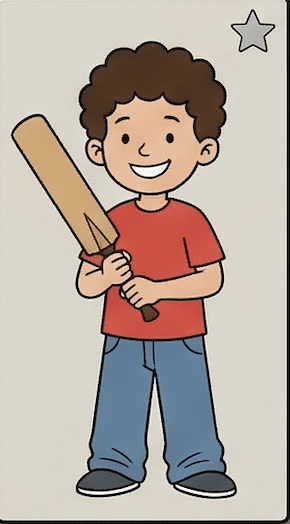

{0: 'Boy in red shirt holding a cricket bat upright, smiling.', 1: 'Boy in batting stance, bat raised behind shoulder, ready.'}
{0: ('Boy in red shirt holding a cricket bat upright, smiling.', 'How many objects present in this image?', 'This image has 1 bat and no ball.'), 1: ('Boy in batting stance, bat raised behind shoulder, ready.', 'How many objects present in this image?', 'This image has 1 bat and no ball.')}
Boy in batting stance, bat raised behind shoulder, ready. 
 How many objects present in this image?,
 This image has 1 bat and no ball.


In [ ]:
import pandas as pd
from datasets import Dataset
import io
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display
from itertools import islice

df = pd.read_parquet('cricket_vqa_bat_ball_count_1_78.parquet')

df['image_id'] = range(len(df))
print("Dataframe Shape:", df.shape)
print(df.head(10))
hf_dataset = Dataset.from_pandas(df.head(80))

# Example of accessing an image from the fixed dataset
image_bytes = hf_dataset[0]['image']['bytes']
image = Image.open(io.BytesIO(image_bytes))
# display(image)

from PIL import Image
import io
import matplotlib.pyplot as plt
from IPython.display import display
from itertools import islice
import time

image_bytes = hf_dataset[0]['image']['bytes']

image = Image.open(io.BytesIO(image_bytes))
display(image)
instruct150k_caption = dict(zip(df['image_id'], df['text'].str.slice(0, 60)))

first_two_items = dict(islice(instruct150k_caption.items(), 2))
print(first_two_items)

instruct150k_qa = dict(zip(df['image_id'], zip(df['text'], df['question'], df['answer'])))

first_two_items = dict(islice(instruct150k_qa.items(), 2))
print(first_two_items)
instruct150k_images = dict(zip(df['image_id'], df['image']))

def get_image(image_id):
    return Image.open(io.BytesIO(instruct150k_images[image_id]['bytes']))


text, question, answer = instruct150k_qa[1]
print(f"{text} \n {question},\n {answer}")


In [ ]:
import os
import json
import torch
import torch.nn as nn
from torch.nn import functional as F
import re
import numpy as np
from PIL import Image
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, DataCollatorWithPadding, AutoProcessor
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPVisionModel, CLIPImageProcessor, CLIPVisionConfig

# Check if CUDA is available
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", torch.cuda.get_device_name(0))  # Print GPU name
else:
    device = torch.device("cpu")
    print("Using CPU")


from huggingface_hub import login
from google.colab import userdata
access_token = userdata.get("hf")
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B",token=access_token)
llama = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-3.2-1B",token=access_token).to(device)

llama.model.embed_tokens
print(f'len(tokenizer 1: {len(tokenizer)}')

tokenizer.pad_token = tokenizer.eos_token
bos_token_id = tokenizer.bos_token_id
pad_token_id = tokenizer.pad_token_id
eos_token_id = tokenizer.eos_token_id
eoi_string = 'caption image:'
eoi_tokens = tokenizer.encode(eoi_string)

print("check again", tokenizer.eos_token_id)
print(f'eoi_tokens : {eoi_tokens}')
print(bos_token_id, pad_token_id, eos_token_id)
print(tokenizer.decode([128000, 128001, 128001]))
print('eoi tokens decoded:', tokenizer.decode(eoi_tokens))
print(len(tokenizer))

vision_model_name = 'openai/clip-vit-base-patch32'

clip_patches = 49
clip_processor = CLIPImageProcessor.from_pretrained(vision_model_name)
clip_model = CLIPVisionModel.from_pretrained(vision_model_name).to(device)




Using GPU: Tesla T4


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

...

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_at

# **Agumentations and Caching**

In [ ]:
image_names_lst = []
for key, value in instruct150k_caption.items():
        image_names_lst.append(key)
print(f'len(image_names_lst) : {len(image_names_lst)}')
print(image_names_lst)
print(instruct150k_caption)


def combine_features(clip_output):
    # Group 1: early layers [0–5], remove CLS
    early = [clip_output.hidden_states[i][:, 1:, :] for i in range(0, 6)]
    image_features_1 = torch.stack(early, dim=0).sum(dim=0) / 6   # [B, 49, 768]

    # Group 2: late layers [6–11], remove CLS
    late = [clip_output.hidden_states[i][:, 1:, :] for i in range(6, 12)]
    image_features_2 = torch.stack(late, dim=0).sum(dim=0) / 6    # [B, 49, 768]

    # Final layer (layer 12 = last_hidden_state), remove CLS
    final_layer = clip_output.last_hidden_state[:, 1:, :]           # [B, 49, 768]

    # 3-way concat like reference DCI
    return torch.cat([final_layer, image_features_1, image_features_2], dim=-1)  # [B, 49, 2304]
    # → requires proj_lin_layer input = 768*3 = 2304

len(image_names_lst) : 78
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77]
{0: 'Boy in red shirt holding a cricket bat upright, smiling.', 1: 'Boy in batting stance, bat raised behind shoulder, ready.', 2: 'Boy resting cricket bat over right shoulder, relaxed pose.', 3: 'Boy holding a tree branch, angry face, X icon shown.', 4: 'Boy holding a straw broom, question mark icon shown.', 5: 'Boy holding a wooden plank, two question marks floating.', 6: 'Boy holding two cricket bats bundled together in one hand.', 7: 'Boy holding one bat in each hand, red X icon shown.', 8: 'Close-up of two hands gripping bat handle, red background.', 9: 'Close-up of hands gripping bat, arrow at hand junction.', 10: 'Boy in relaxed batting stance, bat held ho

In [ ]:
from torchvision import transforms
from tqdm import tqdm
from torchvision import transforms
from tqdm import tqdm

# Diversity pipeline (Hue shift fixes the color bias!)
aug_pipeline = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, hue=0.1),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
])

def create_training_cache(hf_dataset, clip_model, clip_processor, num_variants=1):
    clip_model.eval()
    cache = []
    print("Pre-computing features for speed...")

    with torch.no_grad():
        for i in tqdm(range(len(hf_dataset))):
            img_id = hf_dataset[i]['image_id']
            original_pil = get_image(img_id)
            caption = instruct150k_caption[img_id]
            tokens = tokenizer(caption, truncation=True, padding='max_length', max_length=20, return_tensors="pt")['input_ids']

            for variant_idx in range(num_variants):
                aug_img = original_pil
                # Extract CLIP Hidden States
                inputs = clip_processor(images=aug_img, return_tensors="pt").to(device)
                outputs = clip_model(**inputs, output_hidden_states=True)

                # We save the Last Hidden State (compatible with your current weights)
                # To try "All Layers", you'd concatenate hidden_states[4, 8, 12] here instead
                feat = combine_features(outputs)

                cache.append({
                    'image_id': img_id,
                    'clip_feat': feat,
                    'caption_tokens': tokens.squeeze(0),
                    'caption_text': caption
                })
    torch.save(cache, "augmented_cache.pt")
    print("Cache saved! You can now turn off CLIP to save VRAM.")

# UNCOMMENT AND RUN ONCE:
create_training_cache(hf_dataset, clip_model, clip_processor)
# create_training_cache(hf_dataset.select(range(4)), clip_model, clip_processor)



from torchvision import transforms
from tqdm import tqdm
from torchvision import transforms
from tqdm import tqdm

# Diversity pipeline (Hue shift fixes the color bias!)
aug_pipeline = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, hue=0.1),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
])

def create_training_cache(hf_dataset, clip_model, clip_processor, num_variants=5):
    clip_model.eval()
    cache = []
    print("Pre-computing features for speed...")

    with torch.no_grad():
        for i in tqdm(range(len(hf_dataset))):
            img_id = hf_dataset[i]['image_id']
            original_pil = get_image(img_id)
            caption = instruct150k_caption[img_id]
            tokens = tokenizer(caption, truncation=True, padding='max_length', max_length=20, return_tensors="pt")['input_ids']

            for variant_idx in range(num_variants):
                # Augment and run CLIP once
                aug_img = aug_pipeline(original_pil)
                # Extract CLIP Hidden States
                inputs = clip_processor(images=aug_img, return_tensors="pt").to(device)
                outputs = clip_model(**inputs, output_hidden_states=True)

                # We save the Last Hidden State (compatible with your current weights)
                # To try "All Layers", you'd concatenate hidden_states[4, 8, 12] here instead
                feat = combine_features(outputs)

                cache.append({
                    'image_id': img_id,
                    'clip_feat': feat,
                    'caption_tokens': tokens.squeeze(0),
                    'caption_text': caption
                })
    torch.save(cache, "augmented_cache_variations.pt")
    print("Cache saved! You can now turn off CLIP to save VRAM.")

# UNCOMMENT AND RUN ONCE:
create_training_cache(hf_dataset, clip_model, clip_processor)
# create_training_cache(hf_dataset.select(range(4)), clip_model, clip_processor)

Pre-computing features for speed...


100%|██████████| 78/78 [00:01<00:00, 42.93it/s]


Cache saved! You can now turn off CLIP to save VRAM.
Pre-computing features for speed...


100%|██████████| 78/78 [00:24<00:00,  3.21it/s]


Cache saved! You can now turn off CLIP to save VRAM.


# **Model Code**

In [ ]:
class ClipEmbeddingDataset(Dataset):
    def __init__(self, cache_file):
        self.data = torch.load(cache_file)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

    def collate_fn(self, batch):
        return {
            'clip_feats': torch.stack([item['clip_feat'].squeeze(0) for item in batch]),
            'caption_tokens': torch.stack([item['caption_tokens'] for item in batch]),
            'image_names': [item['image_id'] for item in batch],
            'captions': [item['caption_text'] for item in batch]
        }


class ClipProjectionBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.pre_norm = nn.LayerNorm(channels)

        self.proj = nn.Sequential(
            nn.Linear(channels, channels), # Changed from channels * 2
            nn.GELU(),
            nn.Linear(channels, channels)
        )
    def forward(self, x):
        x = self.pre_norm(x)
        # print("x",x + self.proj(x))
        return x + self.proj(x)


class Phi2ProjModel(nn.Module):
    def __init__(self, clip_model, clip_processor, proj_model, llama, clip_embed_dim=2304, phi2_dim=2048):
        super(Phi2ProjModel, self).__init__()
        self.clip_embed_dim = clip_embed_dim
        self.phi2_dim = phi2_dim
        self.proj_lin_layer = nn.Linear(clip_embed_dim, phi2_dim)
        self.clip_model = clip_model
        self.clip_processor = clip_processor
        self.proj_model = proj_model
        self.llama = llama

    def forward(self, x, target_tokens, target_len, is_precomputed=False):
        if is_precomputed:
            # x is already the CLIP tensor from our cache
            clip_embeddings = x.to(device)
        else:
            # Standard path for individual inference
            inputs = self.clip_processor(images=x, return_tensors="pt").to(device)
            clip_output = self.clip_model(**inputs, output_hidden_states=True)
            clip_embeddings = combine_features(clip_output)

        image_embed = self.proj_lin_layer(clip_embeddings)
        image_embed = self.proj_model(image_embed)

        B, _, C = image_embed.shape
        eoi_tkn_tensor = torch.tensor(eoi_tokens, dtype=torch.int64).to(device)
        eoi_tensor = eoi_tkn_tensor.repeat(B, 1)
        eoi_embed = self.llama.model.embed_tokens(eoi_tensor)
        input_embed = torch.cat([image_embed, eoi_embed], dim=1)

        pred_logits = []
        # Optimization: Prediction loop
        for i in range(target_len):
            output = self.llama.forward(inputs_embeds=input_embed)
            next_word_logit = output.logits[:, -1, :].unsqueeze(1)
            pred_logits.append(next_word_logit)

            # Teacher Forcing: Feed the ground truth back for stable training
            target_tkn = target_tokens[:, i].view(B, 1)
            target_tkn_embed = self.llama.model.embed_tokens(target_tkn)
            input_embed = torch.cat([input_embed, target_tkn_embed], dim=1)

        return torch.cat(pred_logits, dim=1)

In [ ]:
import torch

# Load the cached data files
cached_data_main = torch.load("augmented_cache.pt")
cached_data_variations = torch.load("augmented_cache_variations.pt")

# Merge the two lists of data
cached_data = cached_data_main + cached_data_variations

# Print the number of objects in the merged cache
print(f"Number of objects in merged cached_data: {len(cached_data)}")



def get_embedding_by_image_id(image_id):
    """Retrieves the CLIP embedding for a given image_id from the cached data."""
    for item in cached_data:
        if item['image_id'] == image_id:
            return item['clip_feat']
    return None

torch.save(cached_data, "merged_cache_layer_group_multi.pt")
print("Merged cache saved to merged_cache_multi_layer.pt")

Number of objects in merged cached_data: 468
Merged cache saved to merged_cache_multi_layer.pt


In [ ]:
cached_data_testing_n = torch.load("merged_cache_layer_group_multi.pt")

print(len(cached_data_testing_n))

468


In [ ]:
import torch
cached_data_testing_n = torch.load("merged_cache_layer_group_multi.pt")
def get_embedding_by_image_id(image_id):
    """Retrieves the CLIP embedding for a given image_id from the cached data."""
    for item in cached_data_testing_n:
        if item['image_id'] == image_id:
            return item['clip_feat']
    return None
get_embedding_by_image_id(22)

dataset = ClipEmbeddingDataset("merged_cache_layer_group_multi.pt")
batch_size = 2
dataloader = DataLoader(dataset, batch_size=batch_size, collate_fn=dataset.collate_fn, shuffle=True)


for idx, batch in enumerate(dataloader):
    image_names = batch['image_names']  # List of image names corresponding to each data slice
    captions = batch['captions']  # List of captions corresponding to each data slice
    caption_tokens = batch['caption_tokens']  # Shape: [batch_size, max_seq_len]
    clip_feats = batch['clip_feats']
    print(idx)
    print(image_names)
    print(captions)
    print(caption_tokens.shape, caption_tokens)
    print(clip_feats.shape)
    print('---------')
    if idx > 0:
        break


projection_layer = ClipProjectionBlock(2048).to(device)
phi2_proj_model = Phi2ProjModel(clip_model, clip_processor, projection_layer, llama).to(device).float()

grad_wt_count = 0
non_grad_wt_count = 0
for name, param in phi2_proj_model.named_parameters():
    if "proj_model" in name:
        param.requires_grad = True
        print(name)
        print("proj_model")
        grad_wt_count += 1
    elif "proj_lin_layer" in name:
        print(name)
        param.requires_grad = True
        print("proj_lin_layer")
        grad_wt_count += 1
    else:
        param.requires_grad = False
        non_grad_wt_count += 1
print(f'Parms with grad : {grad_wt_count} & Parms w/o grad : {non_grad_wt_count}')
# optimizer = torch.optim.AdamW(projection_layer.parameters(), lr=1e-3)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, phi2_proj_model.parameters()), lr=1e-5, eps=1e-9)

0
[0, 28]
['Boy in red shirt holding a cricket bat upright, smiling.', "Bird's-eye view of boy in batting-ready stance, dark bg."]
torch.Size([2, 20]) tensor([[128000,  63504,    304,   2579,  15845,  10168,    264,  37099,  16120,
          49685,     11,  37163,     13, 128001, 128001, 128001, 128001, 128001,
         128001, 128001],
        [128000,  66370,    596,  47797,   1684,    315,   8334,    304,  51910,
          65015,  30031,     11,   6453,   9128,     13, 128001, 128001, 128001,
         128001, 128001]])
torch.Size([2, 49, 2304])
---------
1
[64, 8]
['Close-up rear view, upper body, curly hair prominent.', 'Close-up of two hands gripping bat handle, red background.']
torch.Size([2, 20]) tensor([[128000,   8084,   5352,  14981,   1684,     11,   8582,   2547,     11,
          69203,   7013,  21102,     13, 128001, 128001, 128001, 128001, 128001,
         128001, 128001],
        [128000,   8084,   5352,    315,   1403,   6206,  81291,  16120,   3790,
             11, 

In [ ]:
phi2_proj_model.proj_lin_layer.load_state_dict(torch.load('phiproj_ll_load.pth'))
phi2_proj_model.proj_model.load_state_dict(torch.load('phiproj_projm_load.pth'))


<All keys matched successfully>

# **Training**

In [ ]:
# Setup Dataloader with Cache
from torch.distributions import Categorical
def run_train():
    phi2_proj_model.train()
    for idx, batch in enumerate(dataloader):
        clip_feats = batch['clip_feats'].to(device) # Pre-computed!
        target_tokens = batch['caption_tokens'].to(device)
        T_ = target_tokens.shape[1]

        # Use the new is_precomputed=True flag
        pred_logits = phi2_proj_model(clip_feats, target_tokens, T_, is_precomputed=True)

        B, T, C = pred_logits.shape
        loss = F.cross_entropy(pred_logits.view(-1, C), target_tokens.view(-1))

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        torch.cuda.empty_cache()


        print(f'idx: {idx}, loss: {loss} tgt-len: {T_}')
        print(f'****Proj & linear Models saved at idx : {idx}')
        preds = F.softmax(pred_logits, dim=-1).to(torch.float32)
        # top_prob = torch.multinomial(preds, num_samples=1)
        # display_ids = top_prob.view(B, T)
        display_ids = Categorical(probs=preds).sample()
        out_text = tokenizer.batch_decode(display_ids)
        print(f'idx : {idx}')
        print(f"pred: {out_text[0]}")
        print(f"GT: {batch['captions'][0]}")

        if idx % 10 == 0:
            print(f'Batch: {idx}, Loss: {loss.item():.4f}')

# Now training 15 epochs takes minutes, not hours
for epoch in range(5):
    run_train()
    print(str(epoch))
    time.sleep(10)
    # Save weights after each epoch
    torch.save(phi2_proj_model.proj_lin_layer.state_dict(), 'phiproj_ll.pth')
    torch.save(phi2_proj_model.proj_model.state_dict(), 'phiproj_projm.pth')

Streaming output truncated to the last 5000 lines.
idx: 198, loss: 1.0717535018920898 tgt-len: 20
****Proj & linear Models saved at idx : 198
idx : 198
pred: <|begin_of_text|>S holding two bats bats stacked together against one hand.<|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|>
GT: Boy holding two cricket bats bundled together in one hand.
idx: 199, loss: 1.0546518564224243 tgt-len: 20
****Proj & linear Models saved at idx : 199
idx : 199
pred: <|begin_of_text|>Dark jumping forwards, bat raised down, attack screened at fore.<|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|>
GT: Boy bent forward, bat angled down, impact mark at toe.
idx: 200, loss: 0.6968742609024048 tgt-len: 20
****Proj & linear Models saved at idx : 200
idx : 200
pred: <|begin_of_text|>usingagonal bat view, bat side, rect detail, shadow.<|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_

In [ ]:
text_tokens = tokenizer.encode(text)
text_tkn_tensor = torch.tensor(text_tokens, dtype=torch.int64).to(device)
text_tkn_tensor = text_tkn_tensor.unsqueeze(0)
text_embed = phi2_proj_model.llama.model.embed_tokens(text_tkn_tensor)
print("text embd",text_embed)

text embd tensor([[[ 0.0028,  0.0033, -0.0099,  ..., -0.0018,  0.0008,  0.0007],
         [-0.0132,  0.0129, -0.0248,  ..., -0.0085,  0.0007, -0.0050],
         [ 0.0027,  0.0173,  0.0483,  ..., -0.0193,  0.0071, -0.0310],
         ...,
         [ 0.0035, -0.0337,  0.0488,  ..., -0.0140, -0.0154, -0.0349],
         [-0.0112,  0.0094, -0.0244,  ...,  0.0136, -0.0089,  0.0179],
         [-0.0101, -0.0261,  0.0295,  ..., -0.0256, -0.0178,  0.0062]]],
       device='cuda:0')


In [ ]:
text_embed.shape

torch.Size([1, 13, 2048])

# **After Stage 1 Pretraining - Model Inference Check:**

In [ ]:
class Phi2ProjModelPred(nn.Module):
    def __init__(self, clip_model, clip_processor, proj_model, llama, clip_embed_dim=2304, phi2_dim=2048):
        super(Phi2ProjModelPred, self).__init__()
        self.clip_embed_dim = clip_embed_dim
        self.phi2_dim = phi2_dim
        self.proj_lin_layer = nn.Linear(clip_embed_dim, phi2_dim)
        self.clip_model = clip_model
        self.clip_processor = clip_processor
        self.proj_model = proj_model
        self.llama = llama

    def forward(self, input_embed):
        max_len = 50
        output = self.llama.generate(inputs_embeds=input_embed,
                                          max_new_tokens=max_len,
                                          # num_beams=5,             # Look at the top 5 possible sequences
                                          # early_stopping=True,     # Stop when the best path is found
                                          # do_sample=False,         # Keep it deterministic         # Effectively ignored when do_sample=False
                                          return_dict_in_generate = True,
                                          bos_token_id=bos_token_id,
                                          pad_token_id=pad_token_id,
                                          eos_token_id=eos_token_id)

        return output

In [ ]:
phi2_proj_model_pred = Phi2ProjModelPred(phi2_proj_model.clip_model, phi2_proj_model.clip_processor, phi2_proj_model.proj_model, phi2_proj_model.llama).to(device).float()
phi2_proj_model_pred.proj_lin_layer.load_state_dict(torch.load('phiproj_ll_.pth'))
phi2_proj_model_pred.proj_model.load_state_dict(torch.load('phiproj_projm.pth'))


eos_token_id = tokenizer.eos_token_id
bos_token_id = tokenizer.bos_token_id
pad_token_id = tokenizer.pad_token_id
phi2_proj_model_pred.eval()
clip_model.eval()


NameError: name 'Phi2ProjModelPred' is not defined

In [ ]:
def get_inference_features(img, n_augments=10):
    clip_model.eval()
    all_feats = []
    with torch.no_grad():
        for _ in range(n_augments):
            aug_img = aug_pipeline(img)
            inputs = clip_processor(images=aug_img, return_tensors="pt").to(device)
            outputs = clip_model(**inputs, output_hidden_states=True)
            feat = combine_features(outputs)
            all_feats.append(feat)
    return torch.stack(all_feats).mean(dim=0)  # average over augmentations

In [ ]:

def prepare_image_input_embed(img=None,text=None,extra=None):
    audio=None
    input_embed_exists = 0

    inputs_given = []

    if img is not None:
        bos_token = torch.tensor([[tokenizer.bos_token_id]], device=device)
        bos_embed = phi2_proj_model.llama.model.embed_tokens(bos_token) # [1, 1, 2048]
        inputs = clip_processor(images=img, return_tensors="pt").to(device)
        clip_output = clip_model(**inputs, output_hidden_states=True)  # B, 50, 768
        clip_embeddings = get_inference_features(img)     # B, 49, 768

        #clip_embeddings=get_embedding_by_image_id(9)
        image_embed = phi2_proj_model_pred.proj_lin_layer(clip_embeddings)   # B, 49, 2560
        image_embed = phi2_proj_model_pred.proj_model(image_embed)    # B, 49, 2560
        B, _, C = image_embed.shape
        eoi_tkn_tensor = torch.tensor(eoi_tokens, dtype=torch.int64).to(device)  # [4] -> EOI token matrix
        eoi_tensor = eoi_tkn_tensor.repeat(B, 1)  # [B, 4]
        eoi_embed = phi2_proj_model_pred.llama.model.embed_tokens(eoi_tensor)  # B, 4, 2560 -> EOI embeddings (torch.float32)
        input_image_embed = torch.cat([image_embed, eoi_embed], dim=1)
        #input_image_embed  = torch.cat([image_embed], dim=1)  #B, 53, 2560 -> Adding EOI embeddings to indicate end of image
        #input_image_embed = input_image_embed.to(dtype=torch.float16)
        print("image embd",input_image_embed)

    if text is not None:
        text_tkn_tensor = torch.tensor(text, dtype=torch.int64).to(device)  # [4] -> EOI token matrix
        text_tkn_tensor = text_tkn_tensor.unsqueeze(0)
        text_embed = phi2_proj_model.llama.model.embed_tokens(text_tkn_tensor)
        print("text embd",text_embed)

    # If image is present, it gets 1st place in input_embed
    if img is not None:
        input_embed = input_image_embed
        input_embed_exists = 1

    if text:
        # If input_embed is already present, that means image/audio are present. So, append text_embed to it
        if input_embed_exists:
            if audio is not None:
                input_embed = torch.cat([input_embed, text_embed], dim=1)
            else:
                input_embed = torch.cat([input_embed, text_embed], dim=1)
        # If input_embed is not there, that means neither image not audio there. So, give text_embed as input_embed
        else:
            input_embed = text_embed
            input_embed_exists = 1
        inputs_given.append(text)

    # inputs_given.append(eoi_tokens)

    # eoq_tkn_tensor = torch.tensor(eoq_tokens, dtype=torch.int64).to(device)  # [4] -> EOI token matrix
    # B = 1
    # eoq_tensor = eoi_tensor.repeat(B, 1)  # [B, 4]
    # eoq_embed = phi2_proj_model.llama.model.embed_tokens(eoq_tensor)  # B, 4, 2560 -> EOI embeddings (torch.float32)
    # input_embed  = torch.cat([input_embed, eoq_embed], dim=1)
    # 1. Decode the End Of Caption tokens

    # 2. Decode the actual question text tokens
    # Assuming 'text_tokens' is the variable used in your gradio/inference function

    print(f"Question Text: {tokenizer.decode(text)}")

    print("\n--- Full Combined String ---")
    # This is the 'Text' equivalent of the sequence in final_input_embed
    full_string = tokenizer.decode(eoi_tokens) + tokenizer.decode(text)
    print(full_string)

    print("final input embd",input_embed)

    return input_embed.to(phi2_proj_model.llama.dtype)

In [ ]:
def gradio_get_caption_image_fn1(image=None, audio=None, text=None):
    audio_tokens = None
    text_tokens = None

    text = "Close-up of hands gripping bat, arrow at"
    print("text is",text)
    if text:
        text_tokens = tokenizer.encode(text)
        print("text_input",tokenizer.decode(text_tokens))



    if image:
        input_embed = prepare_image_input_embed(image,text_tokens)
        with torch.no_grad():
            output = phi2_proj_model_pred(input_embed)
            print("seq",output.sequences)
            out_text = tokenizer.batch_decode(output.sequences)[0]
            print(out_text)
    else:
        out_text = "I didn't get any input. Give me an image/audio/text or combination of these 3 and get the answer back !"

    return out_text

In [ ]:
import gradio as gr

markdown_description = """
Multimodal llm with image question capabilities
"""
demo = gr.Interface(fn=gradio_get_caption_image_fn1,
                    inputs=[
                            gr.Image(type="pil", label="Image")
                           ],
                    outputs=gr.Textbox(label="Response"),
                    title="Image Caption is",
                    description=markdown_description,
                    article="tp")

demo.queue().launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://709b0ed22040363ca5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 420, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1163, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

text is Close-up of hands gripping bat, arrow at
text_input <|begin_of_text|>Close-up of hands gripping bat, arrow at
image embd tensor([[[ 8.7041e-02, -2.2131e+00, -2.9313e-01,  ..., -4.8905e-01,
          -1.2927e+00,  3.1060e-02],
         [ 4.6527e-02, -2.0137e+00, -4.4364e-01,  ..., -4.3533e-01,
          -1.3571e+00,  3.2855e-01],
         [-1.6447e-01, -1.9646e+00, -4.6529e-01,  ..., -3.2973e-01,
          -1.5394e+00,  1.8979e-01],
         ...,
         [ 1.1719e-02,  4.8096e-02,  2.9907e-02,  ...,  1.2634e-02,
          -3.2471e-02,  1.9775e-02],
         [ 4.0894e-03, -1.2512e-02,  3.0518e-02,  ...,  1.5869e-02,
          -4.4678e-02,  2.8076e-02],
         [-2.3315e-02,  1.0788e-05,  4.4922e-02,  ..., -2.1606e-02,
          -1.3062e-02,  2.0508e-02]]], device='cuda:0', grad_fn=<CatBackward0>)
text embd tensor([[[ 0.0028,  0.0033, -0.0099,  ..., -0.0018,  0.0008,  0.0007],
         [ 0.0070,  0.0133, -0.0240,  ..., -0.0058,  0.0204,  0.0327],
         [ 0.0171, -0.0222,  0.0

# **Stage 2 - Finetuning VQA**

Using GPU: Tesla T4
Dataframe Shape: (78, 6)
   image_id filename                                              image  \
0         0    1.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
1         1    2.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
2         2    3.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
3         3    4.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
4         4    5.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
5         5    6.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
6         6    7.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
7         7    8.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
8         8    9.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
9         9   10.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   

                                                text  \
0  Boy in red shirt holding a cricket bat upright...   
1  Boy in batting

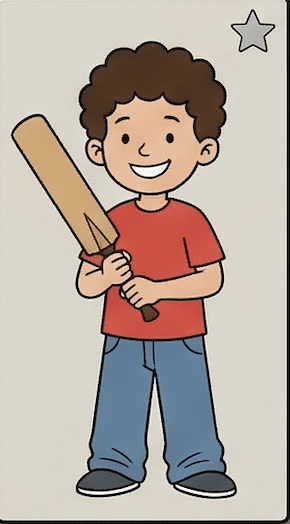

{0: 'Boy in red shirt holding a cricket bat upright, smiling.', 1: 'Boy in batting stance, bat raised behind shoulder, ready.'}
{0: ('Boy in red shirt holding a cricket bat upright, smiling.', 'What is the boy holding in this image?', 'He is holding a wooden cricket bat with both hands.'), 1: ('Boy in batting stance, bat raised behind shoulder, ready.', 'What batting action is the boy preparing?', 'He is raising the bat behind his shoulder to swing.')}
234
Diagonal bat view, front face, ridge visible, shadow. 
 How many objects are present in this image?,
 This image has 1 bat.


In [ ]:
import os
import json
import torch
import torch.nn as nn
from torch.nn import functional as F
import re
import numpy as np
from PIL import Image
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, DataCollatorWithPadding, AutoProcessor
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPVisionModel, CLIPImageProcessor, CLIPVisionConfig
import peft
from peft import LoraConfig

# Check if CUDA is available
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", torch.cuda.get_device_name(0))  # Print GPU name
else:
    device = torch.device("cpu")
    print("Using CPU")


import pandas as pd
from datasets import Dataset
import io
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display
from itertools import islice

# Load the Parquet file
# df = pd.read_parquet('train_data_image_10.parquet')
df = pd.read_parquet('cricket_vqa_dataset_1_78.parquet')
df1 = pd.read_parquet('cricket_vqa_bat_ball_count_1_78.parquet')
df2 = pd.read_parquet('cricket_vqa_all_objects_count_1_78.parquet')


# Fix image_id to be in proper sequence (0, 1, 2, ...) for df
df['image_id'] = range(len(df))

# Adjust image_id for df1 and df2 to ensure uniqueness after concatenation
# df has image_ids 0 to 77. df1 should start from 78.
df1['image_id'] = range(len(df), len(df) + len(df1))
# df2 should start from len(df) + len(df1).
df2['image_id'] = range(len(df) + len(df1), len(df) + len(df1) + len(df2))


# Display first few rows to å
print("Dataframe Shape:", df.shape)
print(df.head(10))

# Combine them. ignore_index=True gives you a fresh index from 0 to 155
df_combined = pd.concat([df, df1, df2], ignore_index=True)

# # Adjust index to be from 1 to 156
# df_combined.index = df_combined.index + 1

# Re-create the HF dataset with the updated dataframe
hf_dataset = Dataset.from_pandas(df_combined)

# Example of accessing an image from the fixed dataset
# image_bytes = hf_dataset[0]['image']['bytes']
# image = Image.Image.open(io.BytesIO(image_bytes))
# display(image)


from PIL import Image
import io
import matplotlib.pyplot as plt
from IPython.display import display
from itertools import islice
import time
from torch.utils.data import Dataset, DataLoader

image_bytes = hf_dataset[0]['image']['bytes']

image = Image.open(io.BytesIO(image_bytes))
display(image)

# Use df_combined's unique image_id as keys for all mappings
instruct150k_caption = dict(zip(df_combined['image_id'], df_combined['text'].str.slice(0, 60)))

first_two_items = dict(islice(instruct150k_caption.items(), 2))
print(first_two_items)

instruct150k_qa = dict(zip(df_combined['image_id'], zip(df_combined['text'], df_combined['question'], df_combined['answer'])))
first_two_items = dict(islice(instruct150k_qa.items(), 2))
print(first_two_items)

# Store all images, indexed by their unique image_id
instruct150k_images = dict(zip(df_combined['image_id'], df_combined['image']))

print(len(instruct150k_qa))

# The virtual_to_physical_map is no longer needed as image_id is now unique and direct.
# Removed virtual_to_physical_map.

def get_image(image_id):
    # Retrieve the image data directly using the (now unique) image_id
    if image_id == 234:
      return Image.open(io.BytesIO(instruct150k_images[233]['bytes']))
    else:
      return Image.open(io.BytesIO(instruct150k_images[image_id]['bytes']))


text, question, answer = instruct150k_qa[233] # Testing with a higher index
print(f"{text} \n {question},\n {answer}")

In [ ]:
print(instruct150k_qa)

{0: ('Boy in red shirt holding a cricket bat upright, smiling.', 'What is the boy holding in this image?', 'He is holding a wooden cricket bat with both hands.'), 1: ('Boy in batting stance, bat raised behind shoulder, ready.', 'What batting action is the boy preparing?', 'He is raising the bat behind his shoulder to swing.'), 2: ('Boy resting cricket bat over right shoulder, relaxed pose.', 'How is the boy carrying the cricket bat?', 'Bat rested over his right shoulder in a relaxed pose.'), 3: ('Boy holding a tree branch, angry face, X icon shown.', 'Is the object the boy holds a cricket bat?', 'No, he holds a tree branch. The X icon confirms error.'), 4: ('Boy holding a straw broom, question mark icon shown.', 'What is unusual about the object he holds?', 'He holds a broom instead of a bat; question mark shown.'), 5: ('Boy holding a wooden plank, two question marks floating.', 'What is the boy holding and why is it wrong?', 'A wooden plank, not a bat; question marks show confusion.')

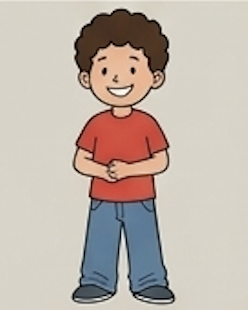

In [ ]:
get_image(135)


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B",token=access_token)
tokenizer.pad_token = tokenizer.eos_token
bos_token_id = tokenizer.bos_token_id
pad_token_id = tokenizer.pad_token_id
eos_token_id = tokenizer.eos_token_id

eoi_string = 'caption image:'
eoi_tokens = tokenizer.encode(eoi_string)
print(f'eoi_tokens : {eoi_tokens}')
eoi_tkn_tensor = torch.tensor(eoi_tokens, dtype=torch.int64).to(device)  # [4] -> EOI token matrix
print(f'eoi_tkn_tensor.shape : {eoi_tkn_tensor.shape} - {eoi_tkn_tensor.get_device()}')

eoq_string = 'end of question:'
eoq_tokens = tokenizer.encode(eoq_string)
print(f'eoq_tokens : {eoq_tokens}')
eoq_tkn_tensor = torch.tensor(eoq_tokens, dtype=torch.int64).to(device)  # [4] -> EOQ token matrix
print(f'eoq_tkn_tensor.shape : {eoq_tkn_tensor.shape} - {eoq_tkn_tensor.get_device()}')

print(bos_token_id, pad_token_id, eos_token_id)
print(tokenizer.decode([50256, 50256, 50256]))
print('eoi tokens decoded:', tokenizer.decode(eoi_tokens))
print('eoq tokens decoded:', tokenizer.decode(eoq_tokens))
print(len(tokenizer))

eoi_tokens : [128000, 24232, 2217, 25]
eoi_tkn_tensor.shape : torch.Size([4]) - 0
eoq_tokens : [128000, 408, 315, 3488, 25]
eoq_tkn_tensor.shape : torch.Size([5]) - 0
128000 128001 128001
parableparableparable
eoi tokens decoded: <|begin_of_text|>caption image:
eoq tokens decoded: <|begin_of_text|>end of question:
128256


In [ ]:
def get_text_by_id(image_id,data):
    if image_id in data:
        # Retrieve the text for the given image_id
        text, _, _ = data[image_id]
        return text

def get_question_by_id(image_id,data):
    if image_id in data:
        # Retrieve the text for the given image_id
        _, question, _ = data[image_id]
        print("question is ",question)
        return question


def get_answer_by_id(image_id,data):
    if image_id in data:
        # Retrieve the text for the given image_id
        _, _, answer = data[image_id]
        print("question is ",answer)
        return answer

class ClipEmbeddingDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.tokenizer = tokenizer
        self.data_collator = DataCollatorWithPadding(tokenizer=self.tokenizer)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        return {
            'image_names': idx,
            'idx': idx,
            'qn_text': get_question_by_id(idx,self.data),
            'ans_text': get_answer_by_id(idx,self.data)
        }

    def tokenize_function(self, caption):
        return self.tokenizer(caption, truncation=True)

    def collate_fn(self, batch):
        image_names = [item['image_names'] for item in batch]
        print("images",image_names)
        qns = [item['qn_text'] for item in batch]
        ans = [item['ans_text'] for item in batch]
        tokenized_qns_lst = []
        for qn in qns:
            print("qn",qn)
            if qn:
              tokenized_qns_dict = self.tokenize_function(qn)
              tokenized_qns_lst.append(tokenized_qns_dict)
        collated_qns = self.data_collator(tokenized_qns_lst)

        tokenized_ans_lst = []
        for an in ans:
            print("an",an)
            if an:
              tokenized_ans_dict = self.tokenize_function(an)
              tokenized_ans_lst.append(tokenized_ans_dict)
        collated_ans = self.data_collator(tokenized_ans_lst)
        qn_tokens = collated_qns['input_ids']
        an_tokens = collated_ans['input_ids']

        return {
            'image_names': image_names,
            'qn': qn_tokens,
            'ans': an_tokens
        }

In [ ]:
get_text_by_id(9,instruct150k_qa)

get_question_by_id(9,instruct150k_qa)
get_answer_by_id(9,instruct150k_qa)




question is  What does the arrow in the image indicate?
question is  Arrow points where both hands meet on bat handle.


'Arrow points where both hands meet on bat handle.'

In [ ]:
dataset = ClipEmbeddingDataset(instruct150k_qa, tokenizer)

batch_size = 2
dataloader = DataLoader(dataset, batch_size=batch_size, collate_fn=dataset.collate_fn, shuffle=True)
print(len(dataset))

for idx, batch in enumerate(dataloader):

    image_names = batch['image_names']  # List of image names corresponding to each data slice
    qn = batch['qn']  # List of captions corresponding to each data slice
    ans = batch['ans']  # Shape: [batch_size, max_seq_len]
    print(tokenizer.decode(batch['qn'][0]))
    print(qn.shape)
    print(ans.shape)
    for i, q in enumerate(qn):
        print(i, tokenizer.decode(q))
    for i, a in enumerate(ans):
        print(i, tokenizer.decode(a))
    print('---------')

234
question is  How many objects present in this image?
question is  This image has 1 bat and no ball.
question is  How many objects present in this image?
question is  This image has no bat and no ball.
images [117, 138]
qn How many objects present in this image?
qn How many objects present in this image?
an This image has 1 bat and no ball.
an This image has no bat and no ball.
<|begin_of_text|>How many objects present in this image?
torch.Size([2, 9])
torch.Size([2, 11])
0 <|begin_of_text|>How many objects present in this image?
1 <|begin_of_text|>How many objects present in this image?
0 <|begin_of_text|>This image has 1 bat and no ball.
1 <|begin_of_text|>This image has no bat and no ball.<|end_of_text|>
---------
question is  How many objects are present in this image?
question is  This image has 1 boy and 1 bat.
question is  What is the background colour in this image?
question is  The background colour is solid red.
images [179, 8]
qn How many objects are present in this image

# **Model Code For VQA**

In [ ]:
class ClipProjectionBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.pre_norm = nn.LayerNorm(channels)

        self.proj = nn.Sequential(
            nn.Linear(channels, channels), # Changed from channels * 2
            nn.GELU(),
            nn.Linear(channels, channels)
        )
    def forward(self, x):
        x = self.pre_norm(x)
        return x + self.proj(x)
class Phi2ProjModel(nn.Module):
    def __init__(self, clip_model, clip_processor, proj_model, llama, clip_embed_dim=2304, phi2_dim=2048):
        super(Phi2ProjModel, self).__init__()
        self.clip_embed_dim = clip_embed_dim
        self.phi2_dim = phi2_dim
        self.proj_lin_layer = nn.Linear(clip_embed_dim, phi2_dim)
        self.clip_model = clip_model
        self.clip_processor = clip_processor
        self.proj_model = proj_model
        self.llama = llama

    def forward(self, x, qn_tokens, ans_tokens):
        inputs = self.clip_processor(images=x, return_tensors="pt").to(device)
        clip_output = self.clip_model(**inputs, output_hidden_states=True)  # B, 50, 768
        clip_embeddings = combine_features(clip_output)     # B, 49, 768
        print("clip_embeddings" , clip_embeddings)
        image_embed = self.proj_lin_layer(clip_embeddings)   # B, 49, 2560
        image_embed = self.proj_model(image_embed)    # B, 49, 2560
        B, _, C = image_embed.shape
        eoi_tensor = eoi_tkn_tensor.repeat(B, 1)  # [B, 4]

        eoi_embed = self.llama.model.model.embed_tokens(eoi_tensor)  # B, 4, 2560 -> EOI embeddings (torch.float32)
        eoq_tensor = eoq_tkn_tensor.repeat(B, 1)  # [B, 4]
        eoq_embed = self.llama.model.model.embed_tokens(eoq_tensor)  # B, 4, 2560 -> EOQ embeddings (torch.float32)
        qn_embed = self.llama.model.model.embed_tokens(qn_tokens)
        ans_embed = self.llama.model.model.embed_tokens(ans_tokens)
        input_embed  = torch.cat([image_embed, eoi_embed, qn_embed, eoq_embed, ans_embed], dim=1)  #B, 49+4+Qn+4+ans, 2560 -> Adding EOI embeddings to indicate end of image
        input_embed = input_embed.to(dtype=torch.float16)
        print("input_embed",input_embed)
        output = self.llama.forward(inputs_embeds = input_embed)
        inputs_given = torch.cat([eoi_tensor, qn_tokens, eoq_tensor, ans_tokens], dim=1)

        return output, input_embed, inputs_given


In [ ]:
lora_alpha = 16
lora_dropout = 0.1
lora_r = 64

peft_config = LoraConfig(
    lora_alpha=lora_alpha,
    lora_dropout=lora_dropout,
    r=lora_r,
    bias="none",
    task_type="CAUSAL_LM"
)

In [ ]:
!pip install -q --upgrade torchao
!pip install -q --upgrade peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 51.5 MB/s eta 0:00:00


In [ ]:
peft_llama = peft.get_peft_model(llama, peft_config)
peft_llama.print_trainable_parameters()

peft_llama.model.model.embed_tokens

projection_layer = ClipProjectionBlock(2048).to(device)

phi2_proj_model = Phi2ProjModel(clip_model, clip_processor, projection_layer, peft_llama).to(device)

trainable params: 6,815,744 || all params: 1,242,630,144 || trainable%: 0.5485


In [ ]:
other_grad_wt_count = 0
clip_grad_wt_count = 0
for name, param in phi2_proj_model.named_parameters():
    if "clip_model" in name:
        param.requires_grad = False
        clip_grad_wt_count += 1
    else:
        other_grad_wt_count += 1
print(f'Parms of clip made non-trainable : {clip_grad_wt_count} & Others untouched parms : {other_grad_wt_count}')


grad_wt_count = 0
non_grad_wt_count = 0
for name, param in phi2_proj_model.named_parameters():
    if param.requires_grad:
        grad_wt_count += 1
    else:
        non_grad_wt_count += 1
print(f'Parms with grad : {grad_wt_count} & Parms w/o grad : {non_grad_wt_count}')


#optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, phi2_proj_model.parameters()), lr=1e-4, eps=1e-9)

# Switch optimizer — keep current weights, just change LRs
optimizer = torch.optim.Adam([
    {'params': phi2_proj_model.proj_lin_layer.parameters(), 'lr': 1e-5},
    {'params': phi2_proj_model.proj_model.parameters(), 'lr': 1e-5},
    {'params': filter(lambda p: p.requires_grad, peft_llama.parameters()), 'lr': 1e-4},
], eps=1e-9)

Parms of clip made non-trainable : 199 & Others untouched parms : 218
Parms with grad : 72 & Parms w/o grad : 345


In [ ]:
phi2_proj_model.proj_lin_layer.load_state_dict(torch.load('phiproj_ll_load.pth'))
phi2_proj_model.proj_model.load_state_dict(torch.load('phiproj_projm_load.pth'))
#phi2_proj_model.llama.load_state_dict(torch.load('llama.pth'))

<All keys matched successfully>

In [ ]:
grad_wt_count = 0
non_grad_wt_count = 0
for name, param in peft_llama.named_parameters():
    if param.requires_grad:
        grad_wt_count += 1
        if name == "base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight":
            print(name, param)
        elif name == "base_model.model.model.layers.31.mlp.fc2.lora_B.default.weight":
            print(name, param)
    else:
        non_grad_wt_count += 1
print(f'Parms with grad : {grad_wt_count} & Parms w/o grad : {non_grad_wt_count}')

base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight Parameter containing:
tensor([[-0.0177,  0.0022, -0.0212,  ...,  0.0208, -0.0165, -0.0053],
        [ 0.0162,  0.0086, -0.0218,  ...,  0.0110,  0.0214, -0.0049],
        [-0.0064, -0.0091, -0.0130,  ..., -0.0097, -0.0191, -0.0023],
        ...,
        [ 0.0109,  0.0206,  0.0065,  ..., -0.0194, -0.0220,  0.0182],
        [ 0.0040,  0.0106,  0.0221,  ...,  0.0143, -0.0060,  0.0174],
        [ 0.0139, -0.0071,  0.0219,  ...,  0.0033, -0.0053,  0.0172]],
       device='cuda:0', requires_grad=True)
Parms with grad : 64 & Parms w/o grad : 146


In [ ]:
# phi2_proj_model.proj_lin_layer.load_state_dict(torch.load('phi2_proj_projm_2_load.pth'))
# phi2_proj_model.proj_model.load_state_dict(torch.load('phi2_proj_model_2_load.pth'))


<All keys matched successfully>

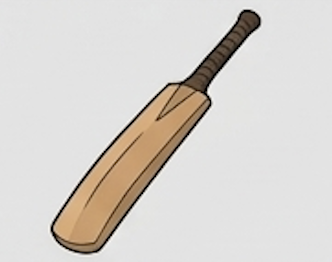

In [ ]:
get_image(234)

In [ ]:
# adapter_path="trained_phi2_gpt_model"
# peft_llama = peft.PeftModel.from_pretrained(llama, adapter_path)

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


# **Training**

In [ ]:
loss_lst = []

def run_train_fine_tune():
  for idx, batch in enumerate(dataloader):
      torch.set_grad_enabled(True)
      pil_img_lst = []
      for image_name in batch['image_names']:
            print("image_name ",image_name)
            image = get_image(image_name)
            if image:
              pil_img_lst.append(image)

      print("length",len(pil_img_lst))

      qn_tokens = batch['qn'].to(device)
      ans_tokens = batch['ans'].to(device)
      target_tokens = batch['ans'].to(device)
      print("target_tokens",target_tokens)
      T_ = target_tokens.shape[-1]  # B, Length of largest answer in batch
      Q_ = qn_tokens.shape[-1] # B, Length of largest qn in batch
      print(f'T_ : {T_}, qn_tokens.shape : {qn_tokens.shape}, target_tokens:{target_tokens.shape}, a:{ans_tokens.shape}')
      # if T_ < 17:

      output, input_embed, inputs_given = phi2_proj_model(pil_img_lst, qn_tokens, target_tokens)  # (B, target_len, 50297)
      print(f'input_embed.shape : {input_embed.shape} output.logits.shape : {output.logits.shape}, inputs_given.shape :{inputs_given.shape}')
      print(len(output))
      print("output",output)
      ans_pos = 49 + 4 + Q_ + 3
      print(f'T_ : {T_+1} == {input_embed.shape[1]-ans_pos}')
      pred_logits = output.logits[:,ans_pos+1:, :]
      print(f'pred_logits.shape : {pred_logits.shape}')

      B, T, C = pred_logits.shape  # (B, target_len, 50297)
      print('B, T, C ',B, T, C)
      pred_logits = pred_logits.reshape(B*T, C)  # B*T, 50297
      print('pred_logits',pred_logits)
      preds = F.softmax(pred_logits, dim=-1).to(torch.float32) # B*T, 50297
      top_prob = torch.multinomial(preds, num_samples=1) # B*T, 1
      display_ids = top_prob.view(B, T)   # B, T

      eos_tensor = torch.full((B, 1), eos_token_id, dtype=torch.int64).to(device)  # B, 1 -> EOS token matrix
      targets = torch.cat((target_tokens, eos_tensor), dim=1)  # B, T_+1 -> Adding EOS token at end of each batch
      # targets = targets[:, 1:]  # Offset by one position
      print('targets',targets)
      tgts = targets.reshape(B * (T_+1)) # B*T_-> Reshaping for loss fn
      print('tgts',tgts)

      #############
      out_text = tokenizer.batch_decode(display_ids)
      in_text = tokenizer.batch_decode(inputs_given)
      print(f'idx : {idx}')
      print(f"inp: {in_text[0]}")
      print(f"pred: {out_text[0]}")
      print(f'tgt: {tokenizer.batch_decode(targets)[0]}')
      print(f"GT-QN: {tokenizer.decode(batch['qn'][0])}")
      print(f"GT-ANS: {tokenizer.decode(batch['ans'][0])}")



      ##########

      # print(f'pred_logits.shape : {pred_logits.shape} tgts.shape : {tgts.shape}')
      loss = F.cross_entropy(pred_logits, tgts)
      # loss.requires_grad = True
      loss.backward()
      loss_lst.append(round(loss.item(),4))
      optimizer.step()
      optimizer.zero_grad()
      # torch.cuda.empty_cache()

      print(f'idx: {idx}, loss: {loss} tgt-len: {T_} Total_len : {ans_pos+T_}')

    # else:
    #     print(f'idx: {idx} Caption too long ! Hence skipping - img_name_b : {img_name_b}, T_: {T_}')

    # if idx > 0:
    #     out_text = tokenizer.batch_decode(display_ids)
    #     in_text = tokenizer.batch_decode(inputs_given)
    #     print(f'idx : {idx}')
    #     print(f"inp: {in_text[0]}")
    #     print(f"pred: {out_text[0]}")
    #     print(f'tgt: {tokenizer.batch_decode(targets)[0]}')
    #     print(f"GT-QN: {tokenizer.decode(batch['qn'][0])}")
    #     print(f"GT-ANS: {tokenizer.decode(batch['ans'][0])}")


In [ ]:
for _ in range(30):
    run_train_fine_tune()
    time.sleep(10)

Streaming output truncated to the last 5000 lines.
         [ 0.8494, -1.7228, -1.7021,  ...,  0.9276,  0.9269,  0.9274],
         [ 0.9461, -2.2021, -1.9022,  ...,  0.8489,  0.8482,  0.8487],
         ...,
         [12.1699,  1.9541,  2.6373,  ..., -1.4732, -1.4746, -1.4747],
         [ 7.6331,  8.0606,  6.2595,  ..., -0.8156, -0.8159, -0.8152],
         [ 8.4612,  5.3126,  4.5141,  ..., -0.1847, -0.1853, -0.1843]],

        [[ 0.8050, -1.6861, -1.6288,  ...,  1.0358,  1.0352,  1.0356],
         [ 0.9165, -1.6139, -1.5330,  ...,  0.7672,  0.7665,  0.7669],
         [ 2.1919, -2.8696, -1.8019,  ...,  0.6516,  0.6510,  0.6514],
         ...,
         [ 2.0645,  1.7225,  1.9167,  ..., -3.1784, -3.1785, -3.1780],
         [11.2690,  2.2484,  0.9789,  ..., -1.4147, -1.4162, -1.4159],
         [ 5.3940,  4.8391,  3.4971,  ..., -0.9098, -0.9102, -0.9093]]],
       device='cuda:0', grad_fn=<UnsafeViewBackward0>), past_key_values=DynamicCache(layers=[DynamicLayer, DynamicLayer, DynamicLayer, D

In [ ]:
torch.save(phi2_proj_model.proj_lin_layer.state_dict(), 'phi2_proj_projm_2.pth')
torch.save(phi2_proj_model.proj_model.state_dict(), 'phi2_proj_model_2.pth')


In [ ]:
peft_llama.save_pretrained("trained_phi2_gpt_model_new")

/usr/local/lib/python3.12/dist-packages/peft/utils/other.py:1394: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-69e760ca-288bd1007f81b3c172cffac2;0ef05ad5-af80-4205-a382-040807e41342)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.2-1B/resolve/main/config.json.
Access to model meta-llama/Llama-3.2-1B is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in meta-llama/Llama-3.2-1B.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:295: UserWarning: Could not find a config file in meta-llama/Llama-3.2-1B - will assume that the vocabulary was not modified.
  warnings.warn(


# **After Stage 2 VQA Training - Model Inference Check:**

In [ ]:

import os
import gc
import json
import torch
import torch.nn as nn
from torch.nn import functional as F
import re
import random
import numpy as np
from PIL import Image
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, DataCollatorWithPadding, AutoProcessor
from transformers import CLIPVisionModel, CLIPImageProcessor, CLIPVisionConfig
import peft
from peft import LoraConfig
from peft import PeftModel
import requests
from io import BytesIO


adapter_path="trained_phi2_gpt_model_new"
merged_phi2 = peft.PeftModel.from_pretrained(llama, adapter_path)


tokenizer.pad_token = tokenizer.eos_token
bos_token_id = tokenizer.bos_token_id
pad_token_id = tokenizer.pad_token_id
eos_token_id = tokenizer.eos_token_id

eoc_string = 'caption image:'
eoc_tokens = tokenizer.encode(eoc_string)
print(f'eoc_tokens : {eoc_tokens}')

eoq_string = 'end of question:'
eoq_tokens = tokenizer.encode(eoq_string)
print(f'eoq_tokens : {eoq_tokens}')

print(bos_token_id, pad_token_id, eos_token_id)
print(tokenizer.decode([50256, 50256, 50256]))
print('eoc tokens decoded:', tokenizer.decode(eoc_tokens))
print('eoq tokens decoded:', tokenizer.decode(eoq_tokens))
print(len(tokenizer))

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


eoc_tokens : [128000, 24232, 2217, 25]
eoq_tokens : [128000, 408, 315, 3488, 25]
128000 128001 128001
parableparableparable
eoc tokens decoded: <|begin_of_text|>caption image:
eoq tokens decoded: <|begin_of_text|>end of question:
128256


In [ ]:
class ClipProjectionBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.pre_norm = nn.LayerNorm(channels)

        self.proj = nn.Sequential(
            nn.Linear(channels, channels), # Changed from channels * 2
            nn.GELU(),
            nn.Linear(channels, channels)
        )
    def forward(self, x):
        x = self.pre_norm(x)
        return x + self.proj(x)

class Phi2ProjModel(nn.Module):
    def __init__(self, clip_model, clip_processor, proj_model, llama, clip_embed_dim=2304, phi2_dim=2048):
        super(Phi2ProjModel, self).__init__()
        self.clip_embed_dim = clip_embed_dim
        self.phi2_dim = phi2_dim
        self.proj_lin_layer = nn.Linear(clip_embed_dim, phi2_dim)
        self.clip_model = clip_model
        self.clip_processor = clip_processor
        self.proj_model = proj_model
        self.llama = llama

    def forward(self, input_embed):
        max_len = 60
        print("shape of input_embed",input_embed.shape)
        output = self.llama.generate(inputs_embeds=input_embed,
                                          max_new_tokens=max_len,
                                          num_beams=5,             # Look at the top 5 possible sequences
                                          early_stopping=True,     # Stop when the best path is found
                                          do_sample=False,         # Keep it deterministic
                                          return_dict_in_generate = True,
                                          output_hidden_states=True,
                                          bos_token_id=bos_token_id,
                                          pad_token_id=bos_token_id,
                                          eos_token_id=bos_token_id)

        return output


projection_layer = ClipProjectionBlock(2048).to(device)

phi2_proj_model = Phi2ProjModel(clip_model, clip_processor, projection_layer, merged_phi2).to(device)

In [ ]:
phi2_proj_model.proj_lin_layer.load_state_dict(torch.load('phi2_proj_projm_2_load.pth'))
phi2_proj_model.proj_model.load_state_dict(torch.load('phi2_proj_model_2_load.pth'))


<All keys matched successfully>

In [ ]:

def prepare_input_embed(img=None, audio=None, text=None, extra=None):

    input_embed_exists = 0

    inputs_given = []

    if img is not None:
        inputs = clip_processor(images=img, return_tensors="pt").to(device)
        clip_output = clip_model(**inputs, output_hidden_states=True)  # B, 50, 768
        clip_embeddings = combine_features(clip_output)     # B, 49, 768
        image_embed = phi2_proj_model.proj_lin_layer(clip_embeddings)   # B, 49, 2560
        image_embed = phi2_proj_model.proj_model(image_embed)    # B, 49, 2560
        B, _, C = image_embed.shape
        eoc_tkn_tensor = torch.tensor(eoc_tokens, dtype=torch.int64).to(device)  # [4] -> EOI token matrix
        eoc_tensor = eoc_tkn_tensor.repeat(B, 1)  # [B, 4]
        eoc_embed = phi2_proj_model.llama.model.model.embed_tokens(eoc_tensor)  # B, 4, 2560 -> EOI embeddings (torch.float32)

        input_image_embed  = torch.cat([image_embed, eoc_embed], dim=1)  #B, 53, 2560 -> Adding EOI embeddings to indicate end of image
        input_image_embed = input_image_embed.to(dtype=torch.float16)
        print("image embd",input_image_embed)

    if text is not None:
        text_tkn_tensor = torch.tensor(text, dtype=torch.int64).to(device)  # [4] -> EOI token matrix
        text_tkn_tensor = text_tkn_tensor.unsqueeze(0)
        text_embed = phi2_proj_model.llama.model.model.embed_tokens(text_tkn_tensor)
        print("text embd",text_embed)

    if extra is not None:
        extra_tkn_tensor = torch.tensor(extra, dtype=torch.int64).to(device)  # [4] -> EOI token matrix
        extra_tkn_tensor = extra_tkn_tensor.unsqueeze(0)
        extra_embed = phi2_proj_model.llama.model.model.embed_tokens(extra_tkn_tensor)
        print("extra embd",extra_embed)


    # If image is present, it gets 1st place in input_embed
    if img is not None:
        input_embed = input_image_embed
        input_embed_exists = 1

    if text:
        # If input_embed is already present, that means image/audio are present. So, append text_embed to it
        if input_embed_exists:
            if audio is not None:
                input_embed = torch.cat([input_embed, text_embed], dim=1)
            else:
                input_embed = torch.cat([input_embed, text_embed], dim=1)
        # If input_embed is not there, that means neither image not audio there. So, give text_embed as input_embed
        else:
            input_embed = text_embed
            input_embed_exists = 1
        inputs_given.append(text)

    inputs_given.append(eoq_tokens)

    print("input given is " , inputs_given)

    eoq_tkn_tensor = torch.tensor(eoq_tokens, dtype=torch.int64).to(device)  # [4] -> EOI token matrix
    B = 1
    eoq_tensor = eoq_tkn_tensor.repeat(B, 1)  # [B, 4]
    eoq_embed = phi2_proj_model.llama.model.model.embed_tokens(eoq_tensor)  # B, 4, 2560 -> EOI embeddings (torch.float32)

    input_embed  = torch.cat([input_embed, eoq_embed,extra_embed], dim=1)
    # else:
    # input_embed  = torch.cat([input_embed, eoq_embed], dim=1)
    print("final input embd",input_embed)

    print("--- Input Sequence Breakdown ---")

# 1. Decode the End Of Caption tokens
    print(f"Image Marker: {tokenizer.decode(eoc_tokens)}")



# 2. Decode the actual question text tokens
# Assuming 'text_tokens' is the variable used in your gradio/inference function

    print(f"Question Text: {tokenizer.decode(text)}")

# 3. Decode the End Of Question tokens
    print(f"Question Closer: {tokenizer.decode(eoq_tokens)}")

    print("\n--- Full Combined String ---")
# This is the 'Text' equivalent of the sequence in final_input_embed
    full_string = tokenizer.decode(eoc_tokens) + tokenizer.decode(text) + tokenizer.decode(eoq_tokens)
    print(full_string)
    return input_embed

In [ ]:
id= 79
text = instruct150k_caption[id]
print(text)

Boy in batting stance, bat raised behind shoulder, ready.


In [ ]:
text, question, answer = instruct150k_qa[id]
print(text, question, answer)

Boy in batting stance, bat raised behind shoulder, ready. How many objects present in this image? This image has 1 bat and no ball.


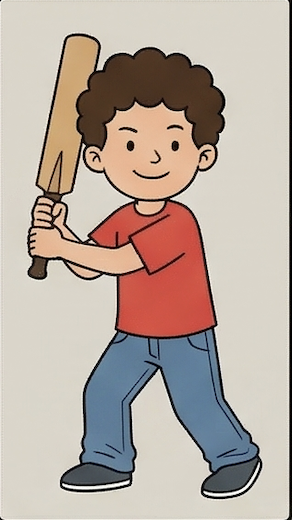

In [ ]:
get_image(id)

In [ ]:
def gradio_get_answers_fn2(image=None, audio=None, text=None):
    audio_tokens = None
    text_tokens = None

    text = "How many objects are present in this image? "
    print("text is",text)
    if text:
        text_tokens = tokenizer.encode(text)
        print("text_input",tokenizer.decode(text_tokens))

    extra = ":<|begin_of_text|>"
    extra_tokens = tokenizer.encode(extra)

    if image:
        if audio or text:
            pass
        else:
            text = "Please describe this image."
            text_tokens = tokenizer.encode(text)
            print("image input",tokenizer.decode(text_tokens))

    if image or audio or text:
        input_embed = prepare_input_embed(image, audio_tokens, text_tokens,extra_tokens)
        with torch.no_grad():
            output = phi2_proj_model(input_embed)
            print("my output is ",output)
            out_text = tokenizer.batch_decode(output.sequences)[0]
            print(out_text)
    else:
        out_text = "I didn't get any input. Give me an image/audio/text or combination of these 3 and get the answer back !"

    return out_text

In [ ]:
import gradio as gr

markdown_description = """
Multimodal llm with image question capabilities
"""
demo = gr.Interface(fn=gradio_get_answers_fn2,
                    inputs=[
                            gr.Image(type="pil", label="Image"),
                            gr.Textbox(info="How may I help you ? please enter your prompt here...", label="Text Query")
                           ],
                    outputs=gr.Textbox(label="Response"),
                    title="Answer image query",
                    description=markdown_description,
                    article="tp")
demo.queue().launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://19f24a00b2e9cc8e4e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Streaming output truncated to the last 5000 lines.
         [-1.1160e+00,  5.6971e-01,  3.2551e-01,  ...,  8.5365e-01,
           6.2905e-01,  5.5371e-01],
         [-1.6708e+00,  7.7566e-01,  4.9806e-01,  ...,  1.7275e+00,
           1.0004e+00,  1.3613e+00],
         ...,
         [ 9.0940e-03, -4.3711e-02,  3.9694e-02,  ...,  6.9942e-03,
           8.2978e-02,  3.6376e-03],
         [-1.4106e-03, -1.5433e-02,  1.1349e-02,  ..., -1.4579e-02,
           8.2040e-03,  4.3659e-02],
         [ 1.3299e-02, -4.4725e-02,  4.1798e-02,  ...,  6.8456e-03,
           8.4732e-02,  2.5426e-03]]], device='cuda:0'), tensor([[[-9.6631e-01,  6.4745e-01,  1.5421e+00,  ...,  1.4150e+00,
           9.8294e-01,  1.2612e+00],
         [-1.2512e+00,  6.7365e-01,  2.9914e-01,  ...,  8.7227e-01,
           8.2234e-01,  5.2977e-01],
         [-1.8067e+00,  8.4115e-01,  4.9151e-01,  ...,  1.7370e+00,
           1.1738e+00,  1.3758e+00],
         ...,
         [ 8.6729e-02, -8.3341e-02,  4.3168e-01,  ...,  2.259

In [ ]:
#Probing

# **Expriments**

# **Part 2 of Blog Series -> Experiment - 3 & 4 Prep for Probing**

In [ ]:

# =============================================================================
# AUGMENTED PROBING DATA PREP
# Reads cricket_vqa_bat_ball_count_1_78.parquet, generates N_AUG augmented
# variants per original image, assigns the same label as the original, and
# restricts to 6 bat/ball-relevant classes.
#
# 6-class label map (bat/ball only — no "boy" classes):
#   0  none
#   1  ball
#   2  bat
#   3  bat_ball
#   4  no_bat
#   5  no_ball
# =============================================================================
import io
import pandas as pd
import torch
from PIL import Image
from torchvision import transforms
from collections import Counter

# ── 6-label map (Entity-Combination focused) ────────────────────────────────
LABEL_MAP_6 = {
    "boy_only":      0,
    "bat_only":      1,
    "boy_bat":       2,
    "boy_ball":      3,
    "boy_bat_ball":  4,
    "improvisation": 5,
    "other": 6,
}

_label_reverse_6 = {v: k for k, v in LABEL_MAP_6.items()}


# Any label not in LABEL_MAP_6 (e.g. boy-only images) is mapped to None
# and filtered out so the probe stays bat/ball-focused.
_KEEP_CLASSES = set(LABEL_MAP_6.keys())

def _infer_label_6(answer: str) -> int:
    """
    Categorizes the scene based on the specific combination of boy, bat, and ball.
    """
    a = answer.lower()

    # 1. Check for Improvisation (Critical for proving visual feature quality)
    # These images contain a 'boy' and an 'object', but it's not a real bat.
    imp_terms = ["branch", "broom", "plank", "log", "wooden"]
    if any(term in a for term in imp_terms):
        return LABEL_MAP_6["improvisation"]

    has_boy  = "boy" in a
    has_bat  = "bat" in a
    has_ball = "ball" in a

    # 2. Logic for Standard Combinations

    # Label 4: Boy + Bat + Ball (Matches IDs 44, 45, 46, 52, 53, 55)
    if has_boy and has_bat and has_ball:
        return LABEL_MAP_6["boy_bat_ball"]

    # Label 2: Boy + Bat (Matches IDs 1-3, 11, 14-22, etc.)
    if has_boy and has_bat:
        return LABEL_MAP_6["boy_bat"]

    # Label 3: Boy + Ball (Matches IDs 43, 56)
    if has_boy and has_ball:
        return LABEL_MAP_6["boy_ball"]

    # Label 1: Bat Only (Strictly NO boy/person mentioned)
    # Matches IDs 9, 10, 23, 30, 41, 70-78
    if has_bat and not has_boy and not has_ball:
        return LABEL_MAP_6["bat_only"]

    # Label 0: Boy Only (Matches IDs 13, 57-69)
    if has_boy and not has_bat and not has_ball:
        return LABEL_MAP_6["boy_only"]

    return LABEL_MAP_6["other"]



# ── Augmentation pipeline (same as training) ─────────────────────────────────
N_AUG = 3   # number of augmented copies per original image

aug_pipeline_probe = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, hue=0.1),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
])

# ── Load parquet ──────────────────────────────────────────────────────────────
BAT_BALL_PARQUET = "cricket_vqa_all_objects_count_1_78.parquet"
df_bb = pd.read_parquet(BAT_BALL_PARQUET, engine="pyarrow")
df_bb['image_id'] = range(len(df_bb))   # ensure clean sequential ids

# Build image lookup: image_id → PIL image
_bb_images = dict(zip(df_bb['image_id'], df_bb['image']))

def _get_pil_image_bb(image_id: int) -> Image.Image:
    return Image.open(io.BytesIO(_bb_images[image_id]['bytes']))

# ── Build augmented probing set ───────────────────────────────────────────────
# Each entry: {'image_id': str, 'pil_img': Image, 'label': int}
# image_id for augmented copies uses a suffix, e.g. "3_aug2".
augmented_probing_set = []

_skipped = 0
for _, row in df_bb.iterrows():
    img_id = int(row['image_id'])
    label  = _infer_label_6(str(row['answer']))

    # 1. Original image (variant 0)
    orig_pil = _get_pil_image_bb(img_id)
    augmented_probing_set.append({
        'image_id':   f"{img_id}_orig",
        'source_id':  img_id,
        'variant':    0,
        'pil_img':    orig_pil,
        'label':      label
    })

    # 2. N_AUG augmented variants
    for aug_idx in range(1, N_AUG + 1):
        aug_pil = aug_pipeline_probe(orig_pil)
        augmented_probing_set.append({
            'image_id':   f"{img_id}_aug{aug_idx}",
            'source_id':  img_id,
            'variant':    aug_idx,
            'pil_img':    aug_pil,
            'label':      label          # same label as original
        })

# ── Summary ───────────────────────────────────────────────────────────────────
_aug_counts = Counter(item['label'] for item in augmented_probing_set)

print(f"\nSource file  : {BAT_BALL_PARQUET}")
print(f"Originals    : {len(df_bb)}")
print(f"Augmented copies per image : {N_AUG}")
print(f"Total samples in augmented_probing_set : {len(augmented_probing_set)}\n")
print("6-class label distribution (originals + augmented):")
for lbl_id, cnt in sorted(_aug_counts.items()):
    print(f"  {lbl_id}  {_label_reverse_6[lbl_id]:<12}  →  {cnt} samples")

print("\nSample entries (first 3 originals, first 3 augmented of image_id=0):")
shown = [e for e in augmented_probing_set if e['source_id'] == 0][:6]
for e in shown:
    print(f"  image_id={e['image_id']:<12}  variant={e['variant']}  label={e['label']} ({_label_reverse_6[e['label']]})")

_label_reverse = {v: k for k, v in LABEL_MAP_6.items()}


Source file  : cricket_vqa_all_objects_count_1_78.parquet
Originals    : 78
Augmented copies per image : 3
Total samples in augmented_probing_set : 312

6-class label distribution (originals + augmented):
  0  boy_only      →  56 samples
  1  bat_only      →  60 samples
  2  boy_bat       →  136 samples
  3  boy_ball      →  8 samples
  4  boy_bat_ball  →  16 samples
  5  improvisation  →  24 samples
  6  other         →  12 samples

Sample entries (first 3 originals, first 3 augmented of image_id=0):
  image_id=0_orig        variant=0  label=2 (boy_bat)
  image_id=0_aug1        variant=1  label=2 (boy_bat)
  image_id=0_aug2        variant=2  label=2 (boy_bat)
  image_id=0_aug3        variant=3  label=2 (boy_bat)


In [ ]:
_label_reverse = {v: k for k, v in LABEL_MAP_6.items()}

In [ ]:

import torch
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split


def prep_input(image=None, text=None):
    audio_tokens = None
    text_tokens = None
    print("text is",text)
    if text:
        text_tokens = tokenizer.encode(text)
        print("text_input",tokenizer.decode(text_tokens))

    extra = ":<|begin_of_text|>"
    extra_tokens = tokenizer.encode(extra)

    if image:
        if text:
            pass
        else:
            text = "Please describe this image."
            text_tokens = tokenizer.encode(text)
            print("image input",tokenizer.decode(text_tokens))

    if image or text:
        return prepare_input_embed(image, audio_tokens, text_tokens,extra_tokens)
    else:
        return None

def get_model_output(model=None, image=None, text=None):
    if image or text:
      input_embed = prep_input(image=image, text=text)
      with torch.no_grad():
            output = model(input_embed)
            print("my output is ",output)
            out_text = tokenizer.batch_decode(output.sequences)[0]
            print(out_text)
    else:
        out_text = "I didn't get any input. Give me an image/audio/text or combination of these 3 and get the answer back !"

    return output, out_text

# Number of image patch tokens that CLIP produces after removing the [CLS].
# clip-vit-base-patch32 on a 224x224 image → 7x7 = 49 patches.
CLIP_IMAGE_TOKENS = 49  # positions 0..48 in the LLM input sequence


def extract_probing_dataset(model, metadata, tokenizer,
                            target_layers=[0, 1, 4, 5, 9, 10, 14, 15],
                            feature_strategy='last_text_token'):
    """
    Extract hidden-state features for probing.

    Args:
        feature_strategy: how to collapse the sequence dimension into a vector.
            'last_text_token' — hidden state of the LAST input-sequence position.
                                In a causal decoder (Phi-2), this token attends
                                over ALL previous positions: every image patch AND
                                every question token.  At layer 0 it is a pure
                                text embedding; at deeper layers it accumulates
                                visual signal step-by-step — producing the rising
                                layer curve you expect in a probing study.
                                USE THIS to demonstrate layer-wise feature build-up.
            'all_token'       — mean over all hidden states (image + text).
                                Noisy because it mixes vision and language positions.
            'image_mean_pool' — mean of hidden states at positions 0..CLIP_IMAGE_TOKENS-1.
                                Those positions can only attend to each other
                                (causal masking keeps text tokens invisible to them),
                                so the representation is essentially the CLIP
                                projection from layer 0 and stays flat across layers.
                                NOT suitable for showing layer-wise progression.
    """
    assert feature_strategy in ('all_token', 'image_mean_pool', 'last_text_token'), (
        f"Unknown feature_strategy '{feature_strategy}'. "
        "Choose 'last_text_token', 'all_token', or 'image_mean_pool'."
    )

    model.eval()
    probing_dataset = []

    with torch.no_grad():
        for item in metadata:
            # Use pre-loaded PIL image when available (e.g. augmented_probing_set
            # has 'pil_img' already set); otherwise fetch by integer image_id.
            img = item['pil_img'] if 'pil_img' in item else get_image(item['image_id'])
            # Neutral prompt — same for every sample so wording can't bias features.
            text = "How many objects are present in this image?"

            input_embed = prep_input(image=[img], text=text)

            gen_output = model.llama.generate(
                inputs_embeds=input_embed,
                max_new_tokens=80,
                num_beams=5,
                early_stopping=True,
                do_sample=False,
                return_dict_in_generate=True,
                bos_token_id=tokenizer.bos_token_id,
                eos_token_id=tokenizer.eos_token_id,
                pad_token_id=tokenizer.pad_token_id
            )
            generated_text = tokenizer.decode(gen_output.sequences[0], skip_special_tokens=True)
            print(f"[{feature_strategy}] image_id={item['image_id']} → {generated_text}")

            # Bare transformer forward — only valid forward-pass kwargs allowed here.
            outputs = model.llama.model(
                inputs_embeds=input_embed,
                output_hidden_states=True,
                return_dict=True
            )

            # hidden_states: tuple of (num_layers + 1) tensors [batch, seq_len, hidden_dim]
            all_states = outputs.hidden_states

            sample_features = {}
            for layer_idx in target_layers:
                h = all_states[layer_idx]  # [1, seq_len, hidden_dim]

                if feature_strategy == 'last_text_token':
                    # The last input token has attended (causally) over every
                    # image patch and every question word.  At shallow layers it
                    # is mostly a text embedding; at deeper layers it progressively
                    # folds in visual context — this is what produces a genuine
                    # layer-wise improvement curve in a probing study.
                    vec = h[0, -1, :]
                elif feature_strategy == 'all_token':
                    # Causal summary: what the model «knows» after reading the
                    # full [image | EOC | question | EOQ] sequence.
                    vec = h[0, :, :].mean(dim=0)
                else:  # 'image_mean_pool'
                    # Vision-focused: average over the 49 image patch positions.
                    # These are the projected CLIP tokens placed at the front of
                    # the sequence, so they carry pure visual signal.
                    n_img = min(CLIP_IMAGE_TOKENS, h.shape[1])
                    vec = h[0, :n_img, :].mean(dim=0)

                sample_features[layer_idx] = vec.cpu().float().numpy()

            probing_dataset.append({
                'image_id':  item['image_id'],
                # Preserve source_id so downstream code can split by source image
                # rather than by individual augmented sample (prevents data leakage).
                'source_id': item.get('source_id', item['image_id']),
                'label':     item['label'],
                'features':  sample_features
            })

    return probing_dataset

target_layers = [0, 1, 4, 5, 9, 10, 14, 15]  # Embed → shallow → middle → deep

# Strategy: last text token (shows genuine layer-wise build-up).
# The final input-sequence token attends causally over ALL image patches
# and question words.  At layer 0 it is a pure text embedding; at deeper
# layers it progressively integrates visual context — giving the rising
# layer curve expected in a probing study.
# image_mean_pool is kept as a reference to contrast the flat CLIP baseline.
dataset_last_text = extract_probing_dataset(
    phi2_proj_model, augmented_probing_set, tokenizer, target_layers,
    feature_strategy='last_text_token'
)
# dataset_img_pool = extract_probing_dataset(
#     phi2_proj_model, augmented_probing_set, tokenizer, target_layers,
#     feature_strategy='image_mean_pool'
# )

# Use last_text_token as the primary dataset for the probing loop below.
dataset = dataset_last_text

text is How many objects are present in this image?
text_input <|begin_of_text|>How many objects are present in this image?


[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Streaming output truncated to the last 5000 lines.
<|begin_of_text|>caption image:<|begin_of_text|>How many objects are present in this image?<|begin_of_text|>end of question:
[last_text_token] image_id=53_aug1 → This image has 3 bats.
text is How many objects are present in this image?
text_input <|begin_of_text|>How many objects are present in this image?
image embd tensor([[[-6.6455e-01,  3.9355e-01,  1.6025e+00,  ...,  1.5801e+00,
          -1.9836e-01,  1.0225e+00],
         [-1.1406e+00,  1.2734e+00,  1.6172e+00,  ...,  1.1465e+00,
           8.1006e-01,  3.9844e-01],
         [-7.3145e-01,  1.5354e-03,  5.5322e-01,  ...,  5.8105e-01,
          -5.1123e-01,  1.5830e+00],
         ...,
         [ 1.1719e-02,  4.8096e-02,  2.9907e-02,  ...,  1.2634e-02,
          -3.2471e-02,  1.9775e-02],
         [ 4.0894e-03, -1.2512e-02,  3.0518e-02,  ...,  1.5869e-02,
          -4.4678e-02,  2.8076e-02],
         [-2.3315e-02,  1.0788e-05,  4.4922e-02,  ..., -2.1606e-02,
          -1.3062e-02,

In [ ]:
# All Layers


=== Strategy: last_text_token (layer-progressive) ===
[last_text_token] Layer 00 | train=248 (src=62) test_orig=16 (src=16) | Macro F1: 0.0526 | Acc: 0.1875 | saved → saved_probes/last_text_token_layer_0.joblib
  Class-level report [last_text_token] Layer 00:
               precision    recall  f1-score   support

     boy_only       0.19      1.00      0.32         3
     bat_only       0.00      0.00      0.00         3
      boy_bat       0.00      0.00      0.00         7
 boy_bat_ball       0.00      0.00      0.00         1
improvisation       0.00      0.00      0.00         1
        other       0.00      0.00      0.00         1

     accuracy                           0.19        16
    macro avg       0.03      0.17      0.05        16
 weighted avg       0.04      0.19      0.06        16

[last_text_token] Layer 01 | train=248 (src=62) test_orig=16 (src=16) | Macro F1: 0.7143 | Acc: 0.9375 | saved → saved_probes/last_text_token_layer_1.joblib
  Class-level report [last_te

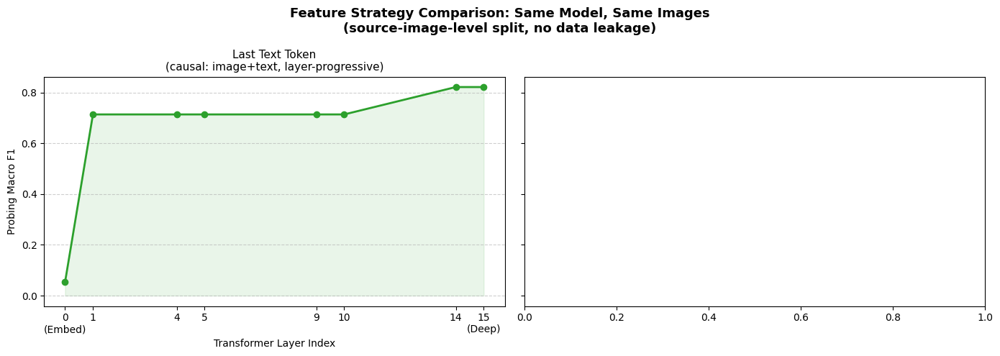

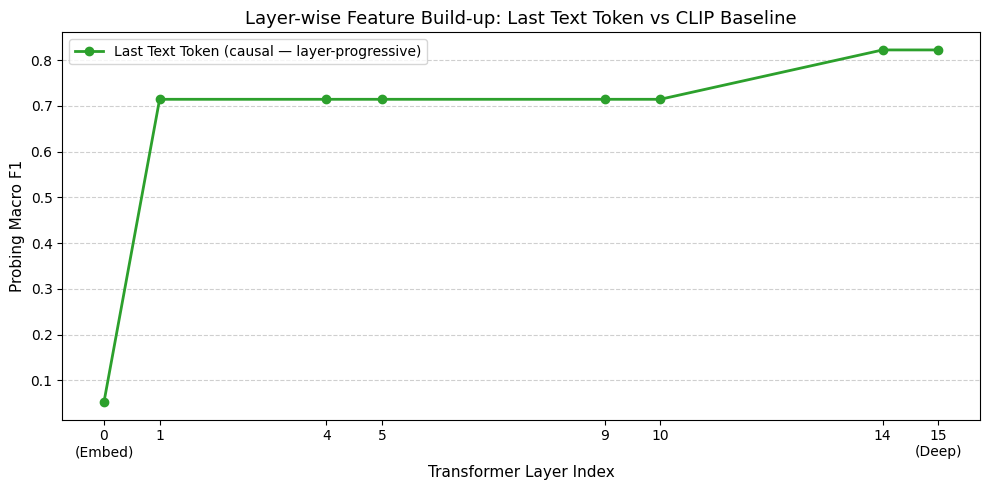

In [ ]:

# =============================================================================
# FEATURE-STRATEGY COMPARISON
# =============================================================================
# Two probing classifiers trained on the SAME model, SAME images, but with
# different ways to collapse hidden states into a fixed-size vector:
#
#   Strategy A — last_token:
#       hidden state of the final input token (current approach).
#       Captures the model's causal summary after reading image + question,
#       but the last positions are question/EOQ tokens, so the vector is
#       influenced by text wording.
#
#   Strategy B — image_mean_pool:
#       mean of hidden states at positions 0..CLIP_IMAGE_TOKENS-1
#       (the 49 projected image patch tokens).
#       Stays vision-focused because it ignores text positions entirely.
#       Expected to carry more cricket-object signal for visual tasks.
#
# If Strategy B scores higher, it confirms the image patch representations
# are the information-rich signal — strengthening the claim that richer
# multi-layer image features matter.
# =============================================================================
from sklearn.metrics import classification_report, confusion_matrix
def _train_probe_on_dataset(dataset_list, target_layers, save_prefix):
    """
    Train one logistic-regression probe per target layer.

    Args:
        dataset_list : output of extract_probing_dataset()
        target_layers: list of layer indices to probe
        save_prefix  : string prepended to saved filenames, e.g. 'last_text_token'

    Returns:
        dict: { layer_idx: {'f1': float, 'acc': float} }

    IMPORTANT — source-image-level split:
        Augmented variants of the same source image are kept in the same fold.
        Splitting at the sample level leaks source-image geometry into the test
        fold (aug variants are near-identical in embedding space), artificially
        inflating all layer F1 scores to 1.0.
        The test fold uses ORIGINAL images only (no augmented variants) for the
        cleanest possible evaluation.
    """
    # ── Source-image-level train/test split ──────────────────────────────────
    # Collect unique source IDs and their representative labels for stratification.
    src_label_map = {}
    for s in dataset_list:
        src_id = s['source_id']
        if src_id not in src_label_map:
            src_label_map[src_id] = s['label']

    unique_src_ids = sorted(src_label_map.keys())
    src_labels     = [src_label_map[sid] for sid in unique_src_ids]

    try:
        train_src_ids, test_src_ids = train_test_split(
            unique_src_ids, test_size=0.2, random_state=42, stratify=src_labels
        )
    except ValueError:
        # Stratification fails when a class has only 1 member — fall back.
        train_src_ids, test_src_ids = train_test_split(
            unique_src_ids, test_size=0.2, random_state=42
        )

    train_src_set = set(train_src_ids)
    test_src_set  = set(test_src_ids)

    # Train: all variants (orig + augmented) of training source images.
    # Test:  ORIGINAL images only from held-out source images — no leakage.
    train_s = [s for s in dataset_list if s['source_id'] in train_src_set]
    test_s  = [s for s in dataset_list
               if s['source_id'] in test_src_set
               and str(s['image_id']).endswith('_orig')]

    results = {}
    for layer_idx in target_layers:
        X_tr = np.array([s['features'][layer_idx] for s in train_s])
        y_tr = np.array([s['label'] for s in train_s])
        X_te = np.array([s['features'][layer_idx] for s in test_s])
        y_te = np.array([s['label'] for s in test_s])

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)

        # C=0.1: moderate L2 regularisation prevents the probe from memorising
        # high-dimensional embeddings on a small dataset.
        # class_weight='balanced': corrects for label imbalance so macro-F1 is
        # meaningful even when some classes (e.g. 'improvisation') are rare.
        clf = LogisticRegression(C=0.1, max_iter=2000, class_weight='balanced')
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_te)

        f1 = f1_score(y_te, preds, average='macro')
        acc = accuracy_score(y_te, preds)
        results[layer_idx] = {'f1': f1, 'acc': acc}

        # Save probe + scaler so both strategies are inspectable offline.
        save_path = f'saved_probes/{save_prefix}_layer_{layer_idx}.joblib'
        joblib.dump({'clf': clf, 'scaler': scaler}, save_path)
        print(f"[{save_prefix}] Layer {layer_idx:02d} | "
              f"train={len(train_s)} (src={len(train_src_ids)}) "
              f"test_orig={len(test_s)} (src={len(test_src_ids)}) | "
              f"Macro F1: {f1:.4f} | Acc: {acc:.4f} | saved → {save_path}")

        # ── Class-level diagnostics ──────────────────────────────────────────
        present_labels = sorted(set(y_te))
        label_names = [_label_reverse.get(l, str(l)) for l in present_labels]
        print(f"  Class-level report [{save_prefix}] Layer {layer_idx:02d}:")
        print(classification_report(y_te, preds,
                                    labels=present_labels,
                                    target_names=label_names,
                                    zero_division=0))

    return results


# print("\n=== Strategy A: last_token ===")
# strategy_results_last_token = _train_probe_on_dataset(
#     dataset_last_token, target_layers, save_prefix='all_token'
# )

print("\n=== Strategy: last_text_token (layer-progressive) ===")
strategy_results_last_text = _train_probe_on_dataset(
    dataset_last_text, target_layers, save_prefix='last_text_token'
)

# print("\n=== Strategy: image_mean_pool (CLIP baseline — expected flat) ===")
# strategy_results_img_pool = _train_probe_on_dataset(
#     dataset_img_pool, target_layers, save_prefix='image_mean_pool'
# )

# --- Side-by-side comparison plot ---
_tick_labels = [str(l) for l in target_layers]
_tick_labels[0] += '\n(Embed)'
_tick_labels[-1] += '\n(Deep)'

f1_last_text = [strategy_results_last_text[l]['f1'] for l in target_layers]
# f1_pool      = [strategy_results_img_pool[l]['f1']  for l in target_layers]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, f1_vals, title, color in [
    (axes[0], f1_last_text, 'Last Text Token\n(causal: image+text, layer-progressive)', '#2ca02c'),
    # (axes[1], f1_pool,      'Image Mean-Pool\n(CLIP baseline — expected flat)',          '#1f77b4'),
]:
    ax.plot(target_layers, f1_vals, marker='o', linewidth=2, color=color)
    ax.fill_between(target_layers, f1_vals, alpha=0.1, color=color)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Transformer Layer Index', fontsize=10)
    ax.set_xticks(target_layers)
    ax.set_xticklabels(_tick_labels)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

axes[0].set_ylabel('Probing Macro F1', fontsize=10)
fig.suptitle('Feature Strategy Comparison: Same Model, Same Images\n'
             '(source-image-level split, no data leakage)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Overlay: directly compare the two strategies
plt.figure(figsize=(10, 5))
plt.plot(target_layers, f1_last_text, 'o-',  color='#2ca02c', linewidth=2,
         label='Last Text Token (causal — layer-progressive)')
# plt.plot(target_layers, f1_pool,      's--', color='#1f77b4', linewidth=2,
#          label='Image Mean-Pool (CLIP baseline — flat)')
# plt.fill_between(target_layers, f1_pool, f1_last_text, alpha=0.08, color='grey',
#                  label='Gap')
plt.title('Layer-wise Feature Build-up: Last Text Token vs CLIP Baseline', fontsize=13)
plt.xlabel('Transformer Layer Index', fontsize=11)
plt.ylabel('Probing Macro F1', fontsize=11)
plt.xticks(target_layers, _tick_labels)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# --- Execution ---

In [ ]:
# Tesing Accuracy

Dataframe Shape: (35, 6)
   image_id filename                                              image  \
0         0    1.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
1         1    2.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
2         2    3.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
3         3    4.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
4         4    5.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
5         5    6.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
6         6    7.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
7         7    8.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
8         8    9.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
9         9   10.png  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   

                                                text  \
0  Boy in red shirt holding cricket bat over left...   
1  Boy in red shirt standing beside c

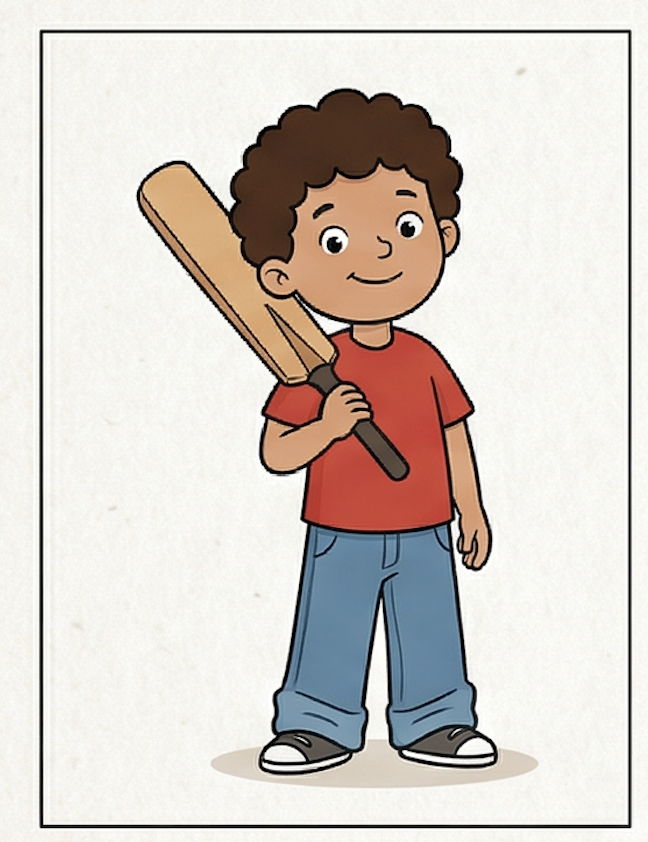

{0: 'Boy in red shirt holding cricket bat over left shoulder, smi', 1: 'Boy in red shirt standing beside cricket bat planted blade-d'}
{0: ('Boy in red shirt holding cricket bat over left shoulder, smiling.', 'How many objects are present in this image?', 'This image has 1 boy and 1 bat.'), 1: ('Boy in red shirt standing beside cricket bat planted blade-down, hand on handle.', 'How many objects are present in this image?', 'This image has 1 boy and 1 bat.')}
Boy in red shirt standing beside cricket bat planted blade-down, hand on handle. 
 How many objects are present in this image?,
 This image has 1 boy and 1 bat.
my label is  2 but answer is  This image has 1 boy and 1 bat.
my label is  2 but answer is  This image has 1 boy and 1 bat.
my label is  2 but answer is  This image has 1 boy and 1 bat.
my label is  2 but answer is  This image has 1 boy and 1 bat.
my label is  2 but answer is  This image has 1 boy and 1 bat.
my label is  1 but answer is  This image has 2 bats.
my label is  

In [ ]:
import pandas as pd
from datasets import Dataset
import io
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display
from itertools import islice

# Load the Parquet file
# df = pd.read_parquet('train_data_image_10.parquet')
# df = pd.read_parquet('cricket_vqa_dataset_1_78.parquet')
df = pd.read_parquet('cricket_vqa_testdata_objects_count_1_35.parquet')


# Fix image_id to be in proper sequence (1, 2, 3, ...)
df['image_id'] = range(len(df))

# Display first few rows to å
print("Dataframe Shape:", df.shape)
print(df.head(10))

# Re-create the HF dataset with the updated dataframe
hf_dataset = Dataset.from_pandas(df.head(80))

# Example of accessing an image from the fixed dataset
image_bytes = hf_dataset[0]['image']['bytes']
image = Image.open(io.BytesIO(image_bytes))
# display(image)


from PIL import Image
import io
import matplotlib.pyplot as plt
from IPython.display import display
from itertools import islice
import time

image_bytes = hf_dataset[0]['image']['bytes']

image = Image.open(io.BytesIO(image_bytes))
display(image)
instruct150k_caption = dict(zip(df['image_id'], df['text'].str.slice(0, 60)))

first_two_items = dict(islice(instruct150k_caption.items(), 2))
print(first_two_items)

instruct150k_qa = dict(zip(df['image_id'], zip(df['text'], df['question'], df['answer'])))

first_two_items = dict(islice(instruct150k_qa.items(), 2))
print(first_two_items)
instruct150k_images = dict(zip(df['image_id'], df['image']))

def get_image(image_id):
    if image_id==29:
      return Image.open(io.BytesIO(instruct150k_images[28]['bytes']))
    else:
      return Image.open(io.BytesIO(instruct150k_images[image_id]['bytes']))


text, question, answer = instruct150k_qa[1]
print(f"{text} \n {question},\n {answer}")




# =============================================================================
# PROBING SET  —  built by reading the saved parquet file
# Only object_count rows are used (one answer per image).
# Labels inferred from answer text: 'bat'/'ball'/'boy' only appear
# when an actual cricket object is present.
# =============================================================================

# =============================================================================
# AUGMENTED PROBING DATA PREP
# Reads cricket_vqa_bat_ball_count_1_78.parquet, generates N_AUG augmented
# variants per original image, assigns the same label as the original, and
# restricts to 6 bat/ball-relevant classes.
#
# 6-class label map (bat/ball only — no "boy" classes):
#   0  none
#   1  ball
#   2  bat
#   3  bat_ball
#   4  no_bat
#   5  no_ball
# =============================================================================
import io
import pandas as pd
import torch
from PIL import Image
from torchvision import transforms
from collections import Counter

# ── 6-label map (Entity-Combination focused) ────────────────────────────────
LABEL_MAP_6 = {
    "boy_only":      0,
    "bat_only":      1,
    "boy_bat":       2,
    "boy_ball":      3,
    "boy_bat_ball":  4,
    "improvisation": 5,
    "ball": 6,
}

_label_reverse_6 = {v: k for k, v in LABEL_MAP_6.items()}


# Any label not in LABEL_MAP_6 (e.g. boy-only images) is mapped to None
# and filtered out so the probe stays bat/ball-focused.
_KEEP_CLASSES = set(LABEL_MAP_6.keys())

def _infer_label_6(answer: str) -> int:
    """
    Categorizes the scene based on the specific combination of boy, bat, and ball.
    """
    a = answer.lower()

    # 1. Check for Improvisation (Critical for proving visual feature quality)
    # These images contain a 'boy' and an 'object', but it's not a real bat.
    imp_terms = ["branch", "broom", "plank", "log", "wooden"]
    if any(term in a for term in imp_terms):
        return LABEL_MAP_6["improvisation"]

    has_boy  = "boy" in a
    has_bat  = "bat" in a
    has_ball = "ball" in a

    # 2. Logic for Standard Combinations

    # Label 4: Boy + Bat + Ball (Matches IDs 44, 45, 46, 52, 53, 55)
    if has_boy and has_bat and has_ball:
        return LABEL_MAP_6["boy_bat_ball"]

    # Label 2: Boy + Bat (Matches IDs 1-3, 11, 14-22, etc.)
    if has_boy and has_bat:
        return LABEL_MAP_6["boy_bat"]

    # Label 3: Boy + Ball (Matches IDs 43, 56)
    if has_boy and has_ball:
        return LABEL_MAP_6["boy_ball"]

    # Label 1: Bat Only (Strictly NO boy/person mentioned)
    # Matches IDs 9, 10, 23, 30, 41, 70-78
    if has_bat and not has_boy and not has_ball:
        return LABEL_MAP_6["bat_only"]

    # Label 0: Boy Only (Matches IDs 13, 57-69)
    if has_boy and not has_bat and not has_ball:
        return LABEL_MAP_6["boy_only"]

    return LABEL_MAP_6["ball"]



# ── Augmentation pipeline (same as training) ─────────────────────────────────
N_AUG = 2   # number of augmented copies per original image

aug_pipeline_probe = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, hue=0.1),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
])

# ── Load parquet ──────────────────────────────────────────────────────────────
BAT_BALL_PARQUET = "cricket_vqa_testdata_objects_count_1_35.parquet"
df_bb = pd.read_parquet(BAT_BALL_PARQUET, engine="pyarrow")
df_bb['image_id'] = range(len(df_bb))   # ensure clean sequential ids

# Build image lookup: image_id → PIL image
_bb_images = dict(zip(df_bb['image_id'], df_bb['image']))

def _get_pil_image_bb(image_id: int) -> Image.Image:
    return Image.open(io.BytesIO(_bb_images[image_id]['bytes']))

# ── Build augmented probing set ───────────────────────────────────────────────
# Each entry: {'image_id': str, 'pil_img': Image, 'label': int}
# image_id for augmented copies uses a suffix, e.g. "3_aug2".
probing_set_only_test = []

_skipped = 0
for _, row in df_bb.iterrows():
    img_id = int(row['image_id'])
    label  = _infer_label_6(str(row['answer']))

    print("my label is ",label ,"but answer is ",str(row['answer']))

    # 1. Original image (variant 0)
    orig_pil = _get_pil_image_bb(img_id)
    probing_set_only_test.append({
        'image_id':   f"{img_id}_orig",
        'source_id':  img_id,
        'variant':    0,
        'pil_img':    orig_pil,
        'label':      label
    })

    # # 2. N_AUG augmented variants
    # for aug_idx in range(1, N_AUG + 1):
    #     aug_pil = aug_pipeline_probe(orig_pil)
    #     probing_set_only_test.append({
    #         'image_id':   f"{img_id}_aug{aug_idx}",
    #         'source_id':  img_id,
    #         'variant':    aug_idx,
    #         'pil_img':    aug_pil,
    #         'label':      label          # same label as original
    #     })

# ── Summary ───────────────────────────────────────────────────────────────────
_aug_counts = Counter(item['label'] for item in probing_set_only_test)

print(f"\nSource file  : {BAT_BALL_PARQUET}")
print(f"Originals    : {len(df_bb)}")
print(f"Augmented copies per image : {N_AUG}")
print(f"Total samples in augmented_probing_set : {len(probing_set_only_test)}\n")
print("6-class label distribution (originals + augmented):")
for lbl_id, cnt in sorted(_aug_counts.items()):
    print(f"  {lbl_id}  {_label_reverse_6[lbl_id]:<12}  →  {cnt} samples")

print("\nSample entries (first 3 originals, first 3 augmented of image_id=0):")
shown = [e for e in probing_set_only_test if e['source_id'] == 0][:6]
for e in shown:
    print(f"  image_id={e['image_id']:<12}  variant={e['variant']}  label={e['label']} ({_label_reverse_6[e['label']]})")

# target_layers=[0, 1, 4,5, 9,10, 14,15]# Initial, Middle, Second-to-last
# # 2. Collect synchronized dataset
# # Assuming probing_set is your list of metadata dicts
# dataset_only_test = extract_probing_test_dataset(phi2_proj_model, probing_set_only_test, tokenizer, target_layers)

target_layers = [0, 1, 4, 5, 9, 10, 14, 15]  # Embed → shallow → middle → deep



text is How many objects are present in this image?
text_input <|begin_of_text|>How many objects are present in this image?
image embd tensor([[[-5.8496e-01,  5.4639e-01,  8.5010e-01,  ...,  1.7188e+00,
           3.4058e-01,  6.6406e-01],
         [-1.5303e+00,  1.0137e+00,  1.8945e+00,  ...,  3.9111e-01,
          -1.0635e+00, -7.7490e-01],
         [-9.0381e-01,  6.6101e-02,  5.5127e-01,  ...,  1.4209e+00,
           9.2041e-01,  1.0811e+00],
         ...,
         [ 1.1719e-02,  4.8096e-02,  2.9907e-02,  ...,  1.2634e-02,
          -3.2471e-02,  1.9775e-02],
         [ 4.0894e-03, -1.2512e-02,  3.0518e-02,  ...,  1.5869e-02,
          -4.4678e-02,  2.8076e-02],
         [-2.3315e-02,  1.0788e-05,  4.4922e-02,  ..., -2.1606e-02,
          -1.3062e-02,  2.0508e-02]]], device='cuda:0', dtype=torch.float16)
text embd tensor([[[ 0.0028,  0.0033, -0.0099,  ..., -0.0018,  0.0008,  0.0007],
         [ 0.0137, -0.0112,  0.0089,  ..., -0.0126,  0.0110, -0.0044],
         [ 0.0009,  0.0189,  

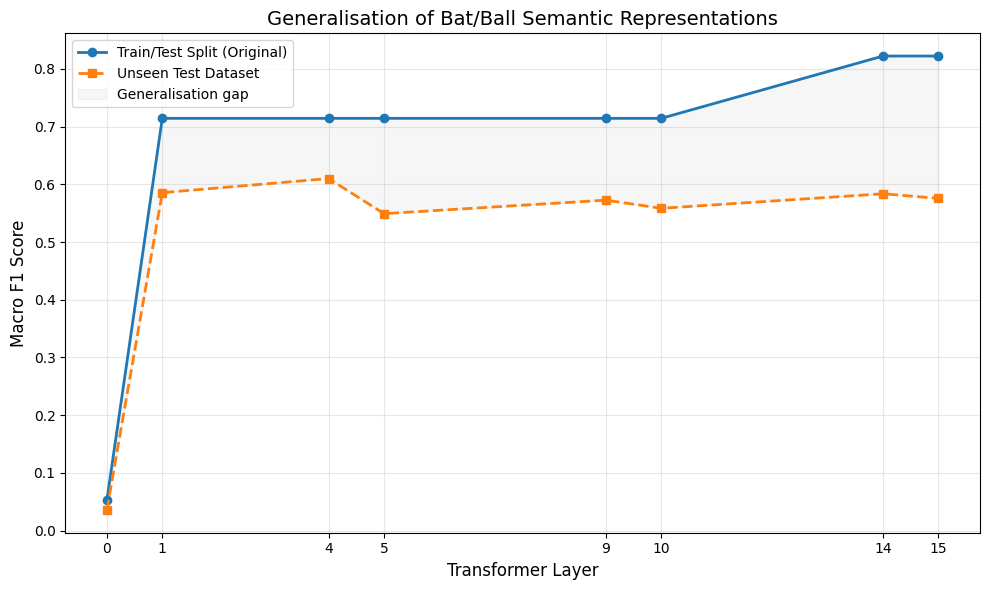


 Layer    Train F1   Unseen F1       Gap
----------------------------------------
     0      0.0526      0.0357   -0.0169
     1      0.7143      0.5855   -0.1288
     4      0.7143      0.6100   -0.1043
     5      0.7143      0.5492   -0.1651
     9      0.7143      0.5725   -0.1417
    10      0.7143      0.5584   -0.1559
    14      0.8222      0.5836   -0.2386
    15      0.8222      0.5756   -0.2467


In [ ]:

def validate_on_new_data(model, new_metadata, tokenizer,
                         target_layers=[0, 1, 4, 5, 9, 10, 14, 15],
                         feature_strategy='last_text_token',
                         save_prefix='last_text_token'):
    """
    Loads saved probes and validates them on a fresh (unseen) dataset.

    Args:
        target_layers    : must match the layers used during training.
        feature_strategy : must match the strategy used during training
                           ('last_text_token', 'image_mean_pool', or 'all_token').
        save_prefix      : prefix used when the probes were saved.
    """
    dataset_val = extract_probing_dataset(
        model, new_metadata, tokenizer,
        target_layers=target_layers,
        feature_strategy=feature_strategy
    )

    validation_results = {}

    for layer_idx in target_layers:
        model_path = f'saved_probes/{save_prefix}_layer_{layer_idx}.joblib'

        if not os.path.exists(model_path):
            print(f"Warning: No saved probe found at {model_path}")
            continue

        saved  = joblib.load(model_path)
        clf    = saved['clf']
        scaler = saved['scaler']

        X_val = np.array([s['features'][layer_idx] for s in dataset_val])
        y_val = np.array([s['label']               for s in dataset_val])

        X_val = scaler.transform(X_val)
        preds = clf.predict(X_val)

        f1  = f1_score(y_val, preds, average='macro')
        acc = accuracy_score(y_val, preds)

        validation_results[layer_idx] = {'f1': f1, 'acc': acc}
        print(f"[{save_prefix}] UNSEEN Layer {layer_idx:02d} | "
              f"Macro F1: {f1:.4f} | Acc: {acc:.4f}")

    return validation_results, dataset_val

# Validate last_text_token probes on the unseen 29-image set
new_results_last_text, dataset_val_last_text = validate_on_new_data(
    phi2_proj_model, probing_set_only_test, tokenizer,
    target_layers=target_layers,
    feature_strategy='last_text_token',
    save_prefix='last_text_token'
)



# Prediction distribution check on the unseen validation data
from collections import Counter
print("\nPrediction distributions on unseen test set (last_text_token probes):")
for layer_idx in target_layers:
    saved = joblib.load(f'saved_probes/last_text_token_layer_{layer_idx}.joblib')
    clf, scaler = saved['clf'], saved['scaler']
    X = np.array([s['features'][layer_idx] for s in dataset_val_last_text])
    preds = clf.predict(scaler.transform(X))
    print(f"  Layer {layer_idx}: {Counter(preds)}")

def plot_validation_comparison(original_results, new_results):
    layers = sorted(original_results.keys())
    # Both dicts now store {'f1': ..., 'acc': ...} — extract the float.
    original_f1 = [original_results[l]['f1'] for l in layers]
    new_f1      = [new_results[l]['f1']      for l in layers]

    tick_labels = [str(l) for l in layers]

    plt.figure(figsize=(10, 6))
    plt.plot(layers, original_f1, 'o-',  label='Train/Test Split (Original)', color='#1f77b4', linewidth=2)
    plt.plot(layers, new_f1,      's--', label='Unseen Test Dataset',          color='#ff7f0e', linewidth=2)
    plt.fill_between(layers, original_f1, new_f1, alpha=0.07, color='grey', label='Generalisation gap')

    plt.title("Generalisation of Bat/Ball Semantic Representations", fontsize=14)
    plt.xlabel("Transformer Layer", fontsize=12)
    plt.ylabel("Macro F1 Score", fontsize=12)
    plt.xticks(layers, tick_labels)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Numeric summary
    print(f"\n{'Layer':>6}  {'Train F1':>10}  {'Unseen F1':>10}  {'Gap':>8}")
    print("-" * 40)
    for l, f_tr, f_un in zip(layers, original_f1, new_f1):
        print(f"{l:>6}  {f_tr:>10.4f}  {f_un:>10.4f}  {f_un - f_tr:>+8.4f}")

plot_validation_comparison(strategy_results_last_text, new_results_last_text)



Confusion-matrix visualisation:
  Train/test fold:  16 original images from held-out source IDs
  Unseen val fold:  35 images from probing_set_only_test

--- Confusion matrices: Train / Test Split ---


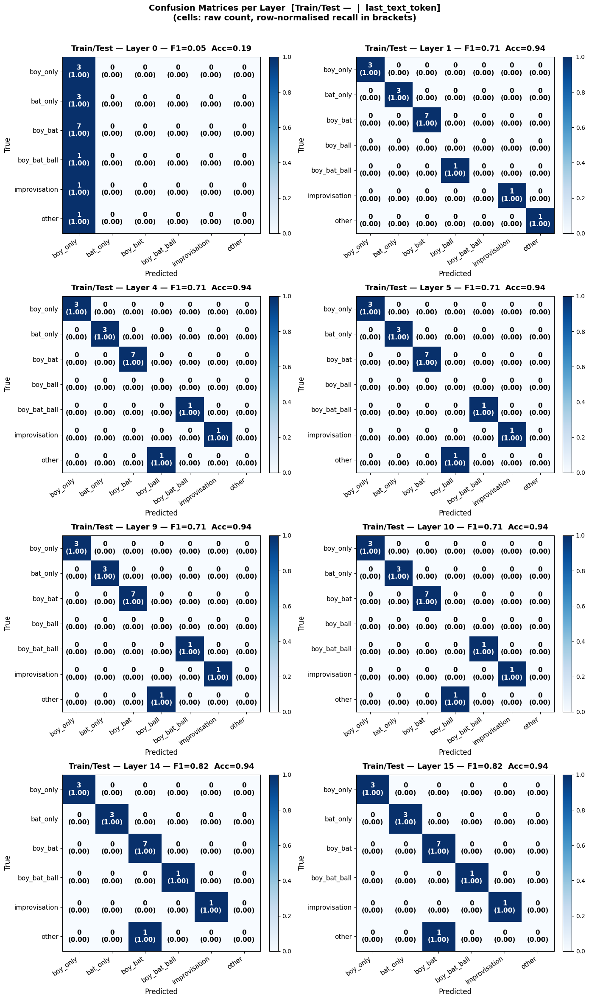

In [ ]:

# =============================================================================
# CONFUSION MATRICES ACROSS ALL LAYERS — TRAINING & VALIDATION
# =============================================================================

def plot_confusion_matrices_all_layers(
    dataset_items,
    target_layers,
    save_prefix,
    label_reverse,
    title_prefix='',
    cmap='Blues',
    figsize_per_cell=(7.0, 6.0),
):
    """
    Plot one confusion matrix per probing layer in a single figure.

    Args:
        dataset_items : list of dicts with 'features' and 'label' keys
                        (output of extract_probing_dataset).
        target_layers : list of layer indices — must match saved probe names.
        save_prefix   : prefix used when probes were saved, e.g. 'last_text_token'.
        label_reverse : dict {int → class_name} for axis tick labels.
        title_prefix  : string prepended to each subplot title.
        cmap          : matplotlib colourmap for the heatmap.
        figsize_per_cell : (width, height) in inches for each subplot cell.
    """
    n_layers = len(target_layers)
    # 2 columns so each matrix gets generous space; compute rows automatically.
    n_cols = min(2, n_layers)
    n_rows = (n_layers + n_cols - 1) // n_cols

    fig_w = figsize_per_cell[0] * n_cols
    fig_h = figsize_per_cell[1] * n_rows
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h))
    # Flatten to 1-D for easy indexing even when n_rows == 1.
    axes_flat = np.array(axes).flatten()

    for ax_idx, layer_idx in enumerate(target_layers):
        ax = axes_flat[ax_idx]

        probe_path = f'saved_probes/{save_prefix}_layer_{layer_idx}.joblib'
        if not os.path.exists(probe_path):
            ax.set_visible(False)
            print(f"  [skip] probe not found: {probe_path}")
            continue

        saved  = joblib.load(probe_path)
        clf    = saved['clf']
        scaler = saved['scaler']

        X = np.array([s['features'][layer_idx] for s in dataset_items])
        y = np.array([s['label']               for s in dataset_items])

        X_scaled = scaler.transform(X)
        preds    = clf.predict(X_scaled)

        present_labels = sorted(set(y) | set(preds))
        label_names    = [label_reverse.get(l, str(l)) for l in present_labels]

        cm = confusion_matrix(y, preds, labels=present_labels)

        # Normalise each row to show recall per class (avoids class-size dominance).
        cm_norm = cm.astype(float)
        row_sums = cm_norm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1           # avoid divide-by-zero
        cm_norm = cm_norm / row_sums

        im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1, aspect='auto')
        cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cb.ax.tick_params(labelsize=10)

        # Annotate each cell with raw count and normalised recall.
        for i in range(len(present_labels)):
            for j in range(len(present_labels)):
                val_norm = cm_norm[i, j]
                val_raw  = cm[i, j]
                text_color = 'white' if val_norm > 0.55 else 'black'
                ax.text(j, i, f'{val_raw}\n({val_norm:.2f})',
                        ha='center', va='center',
                        fontsize=11, fontweight='bold', color=text_color)

        ax.set_xticks(range(len(present_labels)))
        ax.set_yticks(range(len(present_labels)))
        ax.set_xticklabels(label_names, rotation=35, ha='right', fontsize=11)
        ax.set_yticklabels(label_names, fontsize=11)

        macro_f1  = f1_score(y, preds, average='macro', zero_division=0)
        acc       = accuracy_score(y, preds)
        ax.set_title(f'{title_prefix}Layer {layer_idx} — F1={macro_f1:.2f}  Acc={acc:.2f}',
                     fontsize=13, fontweight='bold', pad=10)
        ax.set_xlabel('Predicted', fontsize=12)
        ax.set_ylabel('True', fontsize=12)

    # Hide any unused subplot slots.
    for ax_idx in range(len(target_layers), len(axes_flat)):
        axes_flat[ax_idx].set_visible(False)

    fig.suptitle(
        f'Confusion Matrices per Layer  [{title_prefix.strip()}  |  {save_prefix}]\n'
        '(cells: raw count, row-normalised recall in brackets)',
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


def plot_confusion_matrices_train_vs_val(
    train_dataset,
    val_dataset,
    target_layers,
    save_prefix,
    label_reverse,
    cmap='Blues',
    figsize_per_layer=(14, 6),
):
    """
    Side-by-side confusion matrices for every layer: one figure per layer,
    each figure has 2 subplots — Train/Test (left) | Unseen Validation (right).

    Previous layout (2 rows × 8 columns) produced unreadably tiny cells;
    this version gives every layer its own full-size figure.
    """
    datasets    = [train_dataset,      val_dataset]
    split_names = ['Train / Test Split', 'Unseen Validation']
    cmaps       = ['Blues',              'Oranges']

    for layer_idx in target_layers:
        probe_path = f'saved_probes/{save_prefix}_layer_{layer_idx}.joblib'
        if not os.path.exists(probe_path):
            print(f"  [skip] probe not found: {probe_path}")
            continue

        saved  = joblib.load(probe_path)
        clf    = saved['clf']
        scaler = saved['scaler']

        fig, axes = plt.subplots(1, 2, figsize=figsize_per_layer)

        for ax, ds, split_name, cm_cmap in zip(axes, datasets, split_names, cmaps):
            X = np.array([s['features'][layer_idx] for s in ds])
            y = np.array([s['label']               for s in ds])

            X_scaled = scaler.transform(X)
            preds    = clf.predict(X_scaled)

            present_labels = sorted(set(y) | set(preds))
            label_names    = [label_reverse.get(l, str(l)) for l in present_labels]

            cm = confusion_matrix(y, preds, labels=present_labels)

            cm_norm = cm.astype(float)
            row_sums = cm_norm.sum(axis=1, keepdims=True)
            row_sums[row_sums == 0] = 1
            cm_norm = cm_norm / row_sums

            im = ax.imshow(cm_norm, cmap=cm_cmap, vmin=0, vmax=1, aspect='auto')
            cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cb.ax.tick_params(labelsize=10)

            for i in range(len(present_labels)):
                for j in range(len(present_labels)):
                    val_norm = cm_norm[i, j]
                    val_raw  = cm[i, j]
                    text_color = 'white' if val_norm > 0.55 else 'black'
                    ax.text(j, i, f'{val_raw}\n({val_norm:.2f})',
                            ha='center', va='center',
                            fontsize=11, fontweight='bold', color=text_color)

            ax.set_xticks(range(len(present_labels)))
            ax.set_yticks(range(len(present_labels)))
            ax.set_xticklabels(label_names, rotation=35, ha='right', fontsize=11)
            ax.set_yticklabels(label_names, fontsize=11)

            macro_f1 = f1_score(y, preds, average='macro', zero_division=0)
            acc      = accuracy_score(y, preds)
            ax.set_title(f'{split_name}\nF1={macro_f1:.2f}  Acc={acc:.2f}',
                         fontsize=13, fontweight='bold', pad=10)
            ax.set_xlabel('Predicted', fontsize=12)
            ax.set_ylabel('True', fontsize=12)

        fig.suptitle(
            f'Layer {layer_idx} — Train/Test vs Unseen Validation  [{save_prefix}]\n'
            '(cells: raw count, row-normalised recall in brackets)',
            fontsize=14, fontweight='bold'
        )
        plt.tight_layout(rect=[0, 0, 1, 0.93])
        plt.show()


# ── Rebuild the held-out test fold so it mirrors what was used during training ─
# We need the same source-image-level split that _train_probe_on_dataset used.
_src_lbl_map_vis = {}
for s in dataset_last_text:
    sid = s['source_id']
    if sid not in _src_lbl_map_vis:
        _src_lbl_map_vis[sid] = s['label']

_unique_src_vis  = sorted(_src_lbl_map_vis.keys())
_src_labels_vis  = [_src_lbl_map_vis[sid] for sid in _unique_src_vis]

try:
    _train_src_vis, _test_src_vis = train_test_split(
        _unique_src_vis, test_size=0.2, random_state=42, stratify=_src_labels_vis
    )
except ValueError:
    _train_src_vis, _test_src_vis = train_test_split(
        _unique_src_vis, test_size=0.2, random_state=42
    )

_test_src_set_vis = set(_test_src_vis)
# Test fold: original images only (matches _train_probe_on_dataset convention).
test_samples_vis = [
    s for s in dataset_last_text
    if s['source_id'] in _test_src_set_vis
    and str(s['image_id']).endswith('_orig')
]

print(f"\nConfusion-matrix visualisation:")
print(f"  Train/test fold:  {len(test_samples_vis)} original images from held-out source IDs")
print(f"  Unseen val fold:  {len(dataset_val_last_text)} images from probing_set_only_test")

# ── 1. Per-layer confusion matrices for the TRAIN/TEST split ─────────────────
print("\n--- Confusion matrices: Train / Test Split ---")
plot_confusion_matrices_all_layers(
    dataset_items  = test_samples_vis,
    target_layers  = target_layers,
    save_prefix    = 'last_text_token',
    label_reverse  = _label_reverse,
    title_prefix   = 'Train/Test — ',
)




--- Confusion matrices: Unseen Validation ---


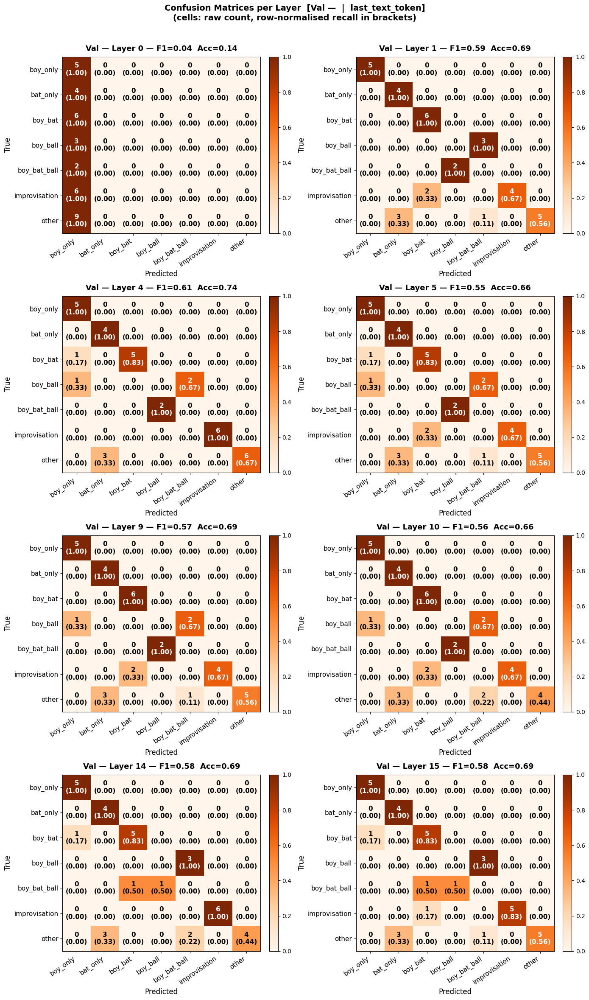

In [ ]:
# ── 2. Per-layer confusion matrices for the UNSEEN VALIDATION set ─────────────
print("\n--- Confusion matrices: Unseen Validation ---")
plot_confusion_matrices_all_layers(
    dataset_items  = dataset_val_last_text,
    target_layers  = target_layers,
    save_prefix    = 'last_text_token',
    label_reverse  = _label_reverse,
    title_prefix   = 'Val — ',
    cmap           = 'Oranges',
)


In [ ]:


# ── 3. Combined side-by-side (2 rows × 8 layers) ─────────────────────────────
print("\n--- Side-by-side confusion matrices: Train vs Validation ---")
plot_confusion_matrices_train_vs_val(
    train_dataset  = test_samples_vis,
    val_dataset    = dataset_val_last_text,
    target_layers  = target_layers,
    save_prefix    = 'last_text_token',
    label_reverse  = _label_reverse,
)

In [ ]:

# =============================================================================
# HUE STRESS TEST WITH CONFUSION MATRICES
# Runs hue/color-jitter stress on BOTH training and validation probing datasets.
# For each dataset prints:
#   - Side-by-side confusion matrices (original vs hue-distorted)
#   - Per-class accuracy comparison table
#   - Overall macro F1 / accuracy summary
# Reuses the row-normalised CM style from plot_confusion_matrices_all_layers.
# =============================================================================

_hue_only_transform = transforms.ColorJitter(hue=0.4, brightness=0.2)


def run_hue_stress_test_with_cm(model, metadata, layer_idx, probe_file,
                                 dataset_label='Dataset'):
    """
    Hue stress test with confusion matrices and per-class accuracy breakdown.

    Args:
        model         : phi2_proj_model
        metadata      : list of probing dicts with 'pil_img' (or 'source_id')
                        and 'label' keys.
        layer_idx     : transformer layer to probe (e.g. 15).
        probe_file    : path to saved .joblib probe {'clf': ..., 'scaler': ...}.
        dataset_label : display name used in titles/prints.
    """
    model.eval()

    saved  = joblib.load(probe_file)
    clf    = saved['clf']
    scaler = saved['scaler']

    original_preds  = []
    distorted_preds = []
    ground_truth    = []
    sample_images   = []   # (orig_pil, dist_pil, gt, pred_orig, pred_dist)

    print(f"\n[{dataset_label}] Hue Stress Test — Layer {layer_idx} | "
          f"{len(metadata)} samples")

    with torch.no_grad():
        for i, item in enumerate(metadata):
            img   = item.get('pil_img') or get_image(item['source_id'])
            label = item['label']
            ground_truth.append(label)

            # --- Path A: Original ---
            inp_orig  = prep_input(image=[img], text="How many objects are present?")
            out_orig  = model.llama.model(inputs_embeds=inp_orig,
                                               output_hidden_states=True)
            feat_orig = out_orig.hidden_states[layer_idx][0, -1, :].cpu().float().numpy()
            pred_orig = clf.predict(scaler.transform(feat_orig.reshape(1, -1)))[0]
            original_preds.append(pred_orig)

            # --- Path B: Hue-Distorted ---
            img_dist  = _hue_only_transform(img)
            inp_dist  = prep_input(image=[img_dist], text="How many objects are present?")
            out_dist  = model.llama.model(inputs_embeds=inp_dist,
                                               output_hidden_states=True)
            feat_dist = out_dist.hidden_states[layer_idx][0, -1, :].cpu().float().numpy()
            pred_dist = clf.predict(scaler.transform(feat_dist.reshape(1, -1)))[0]
            distorted_preds.append(pred_dist)

            if i < 15:
                sample_images.append((img, img_dist, label, pred_orig, pred_dist))

    ground_truth    = np.array(ground_truth)
    original_preds  = np.array(original_preds)
    distorted_preds = np.array(distorted_preds)

    # ── Overall metrics ───────────────────────────────────────────────────────
    acc_orig = accuracy_score(ground_truth, original_preds)
    acc_dist = accuracy_score(ground_truth, distorted_preds)
    f1_orig  = f1_score(ground_truth, original_preds,  average='macro', zero_division=0)
    f1_dist  = f1_score(ground_truth, distorted_preds, average='macro', zero_division=0)
    drop_acc = (acc_orig - acc_dist) / acc_orig * 100 if acc_orig > 0 else 0.0
    drop_f1  = (f1_orig  - f1_dist)  / f1_orig  * 100 if f1_orig  > 0 else 0.0

    print(f"\n  Overall  —  Original: Acc={acc_orig:.4f}  Macro F1={f1_orig:.4f}")
    print(f"             Hue-Shift: Acc={acc_dist:.4f}  Macro F1={f1_dist:.4f}")
    print(f"             Acc Drop : {drop_acc:.2f}%    F1 Drop: {drop_f1:.2f}%")

    # ── Per-class accuracy ────────────────────────────────────────────────────
    present_labels = sorted(set(ground_truth))
    label_names    = [_label_reverse.get(l, str(l)) for l in present_labels]

    print(f"\n  {'Class':<18} {'Orig Acc':>10} {'Hue Acc':>10} {'Drop':>10}  {'N':>4}")
    print("  " + "-" * 58)
    for lbl, lname in zip(present_labels, label_names):
        mask      = ground_truth == lbl
        n         = mask.sum()
        if n == 0:
            continue
        acc_c_orig = (original_preds[mask]  == lbl).mean()
        acc_c_dist = (distorted_preds[mask] == lbl).mean()
        drop_c     = (acc_c_orig - acc_c_dist) * 100
        flag       = " ◄ large drop" if drop_c > 15 else ""
        print(f"  {lname:<18} {acc_c_orig:>10.4f} {acc_c_dist:>10.4f} "
              f"{drop_c:>+9.1f}%  {n:>4}{flag}")

    # Full per-class classification reports
    print(f"\n  --- Original Classification Report [{dataset_label}] ---")
    print(classification_report(ground_truth, original_preds,
                                labels=present_labels, target_names=label_names,
                                zero_division=0))
    print(f"  --- Hue-Shifted Classification Report [{dataset_label}] ---")
    print(classification_report(ground_truth, distorted_preds,
                                labels=present_labels, target_names=label_names,
                                zero_division=0))

    # ── Confusion matrices — reuse row-normalised style ───────────────────────
    def _draw_cm(y_true, y_pred, title, ax, cmap):
        present = sorted(set(y_true) | set(y_pred))
        lnames  = [_label_reverse.get(l, str(l)) for l in present]
        cm      = confusion_matrix(y_true, y_pred, labels=present)
        cm_norm = cm.astype(float)
        row_sums = cm_norm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm_norm /= row_sums

        im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1, aspect='auto')
        cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cb.ax.tick_params(labelsize=9)

        for i in range(len(present)):
            for j in range(len(present)):
                val_norm = cm_norm[i, j]
                val_raw  = cm[i, j]
                color    = 'white' if val_norm > 0.55 else 'black'
                ax.text(j, i, f'{val_raw}\n({val_norm:.2f})',
                        ha='center', va='center',
                        fontsize=10, fontweight='bold', color=color)

        ax.set_xticks(range(len(present)))
        ax.set_yticks(range(len(present)))
        ax.set_xticklabels(lnames, rotation=35, ha='right', fontsize=10)
        ax.set_yticklabels(lnames, fontsize=10)
        ax.set_xlabel('Predicted', fontsize=11)
        ax.set_ylabel('True',      fontsize=11)
        mf1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        acc_v = accuracy_score(y_true, y_pred)
        ax.set_title(f'{title}\nF1={mf1:.2f}  Acc={acc_v:.2f}',
                     fontsize=12, fontweight='bold', pad=8)

    fig_cm, axes_cm = plt.subplots(1, 2, figsize=(14, 6))
    _draw_cm(ground_truth, original_preds,
             f'Original — {dataset_label}  Layer {layer_idx}',
             axes_cm[0], cmap='Blues')
    _draw_cm(ground_truth, distorted_preds,
             f'Hue-Shifted — {dataset_label}  Layer {layer_idx}',
             axes_cm[1], cmap='Reds')
    fig_cm.suptitle(
        f'Hue Stress Test: Original vs Hue-Shifted  [{dataset_label} | Layer {layer_idx}]\n'
        f'(cells: raw count, row-normalised recall in brackets)',
        fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

    # ── Sample image pairs ────────────────────────────────────────────────────
    if sample_images:
        n_show   = len(sample_images)
        fig_s, axes_s = plt.subplots(n_show, 2, figsize=(8, 3 * n_show))
        if n_show == 1:
            axes_s = [axes_s]
        for idx_s, (orig, dist, gt, p_o, p_d) in enumerate(sample_images):
            axes_s[idx_s][0].imshow(orig)
            axes_s[idx_s][0].set_title(
                f"Original\nGT: {_label_reverse.get(gt, gt)}\n"
                f"Pred: {_label_reverse.get(p_o, p_o)}", fontsize=9)
            axes_s[idx_s][0].axis('off')
            axes_s[idx_s][1].imshow(dist)
            axes_s[idx_s][1].set_title(
                f"Hue-Shifted\nGT: {_label_reverse.get(gt, gt)}\n"
                f"Pred: {_label_reverse.get(p_d, p_d)}", fontsize=9)
            axes_s[idx_s][1].axis('off')
        fig_s.suptitle(f'Sample Pairs — {dataset_label}', fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.show()

    return {
        'acc_orig': acc_orig, 'acc_dist': acc_dist,
        'f1_orig':  f1_orig,  'f1_dist':  f1_dist,
        'original_preds':  original_preds,
        'distorted_preds': distorted_preds,
        'ground_truth':    ground_truth,
    }

# **Experiment 3 - Probing Visual Grounding Robustness under Blur Corruption**

BLUR STRESS TEST WITH CM — TEST / VALIDATION DATASET

[Validation (unseen)] Blur Stress Test (Sigma=8.0) — Layer 15 | 35 samples
text is How many objects are present?
text_input <|begin_of_text|>How many objects are present?
image embd tensor([[[-5.8496e-01,  5.4639e-01,  8.5010e-01,  ...,  1.7188e+00,
           3.4058e-01,  6.6406e-01],
         [-1.5303e+00,  1.0137e+00,  1.8945e+00,  ...,  3.9111e-01,
          -1.0635e+00, -7.7490e-01],
         [-9.0381e-01,  6.6101e-02,  5.5127e-01,  ...,  1.4209e+00,
           9.2041e-01,  1.0811e+00],
         ...,
         [ 1.1719e-02,  4.8096e-02,  2.9907e-02,  ...,  1.2634e-02,
          -3.2471e-02,  1.9775e-02],
         [ 4.0894e-03, -1.2512e-02,  3.0518e-02,  ...,  1.5869e-02,
          -4.4678e-02,  2.8076e-02],
         [-2.3315e-02,  1.0788e-05,  4.4922e-02,  ..., -2.1606e-02,
          -1.3062e-02,  2.0508e-02]]], device='cuda:0', dtype=torch.float16)
text embd tensor([[[ 0.0028,  0.0033, -0.0099,  ..., -0.0018,  0.0008,  0.0007],

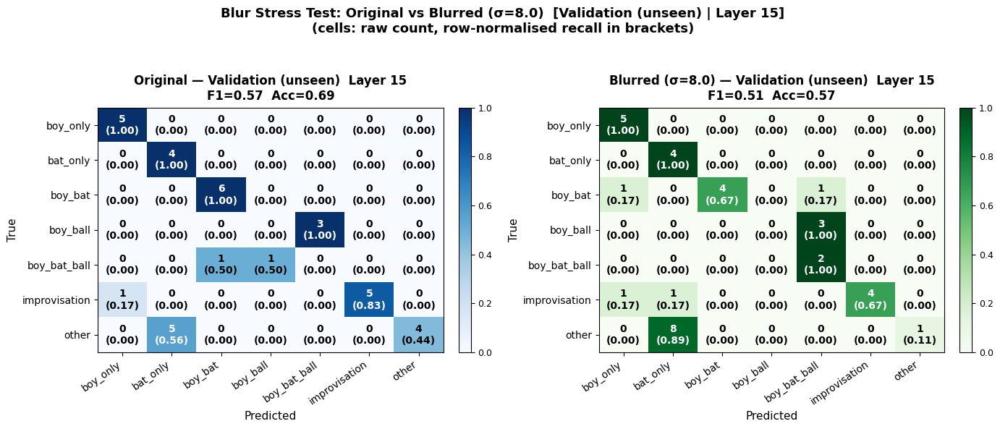

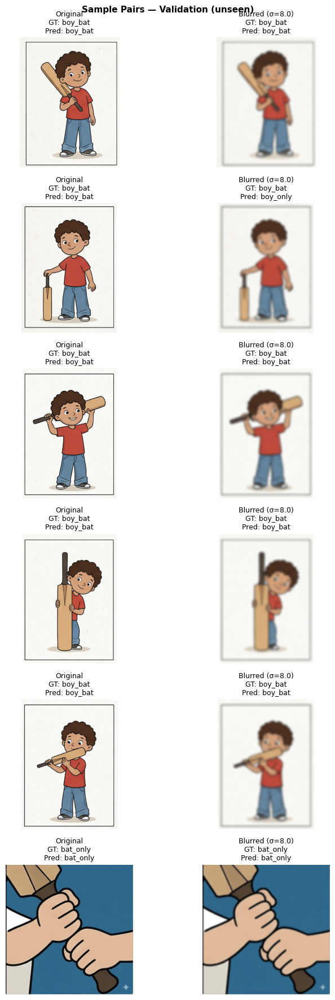

In [ ]:

# =============================================================================
# BLUR STRESS TEST WITH CONFUSION MATRICES — TEST DATASET ONLY
# Side-by-side CMs (original vs blurred), per-class accuracy comparison,
# and summary. Reuses row-normalised CM style from plot_confusion_matrices_all_layers.
# =============================================================================

def run_blur_stress_test_with_cm(model, metadata, layer_idx, probe_file,
                                  sigma=4.0, dataset_label='Test'):
    """
    Single-sigma blur stress test on the test dataset with:
      - Side-by-side confusion matrices (original vs blurred)
      - Per-class accuracy comparison table
      - Overall accuracy / macro F1 summary
    """
    model.eval()

    saved  = joblib.load(probe_file)
    clf    = saved['clf']
    scaler = saved['scaler']

    kernel_size = int(4 * sigma + 1)
    if kernel_size % 2 == 0:
        kernel_size += 1
    blur_transform = transforms.GaussianBlur(kernel_size=(kernel_size, kernel_size), sigma=sigma)

    original_preds  = []
    distorted_preds = []
    ground_truth    = []
    sample_images   = []

    print(f"\n[{dataset_label}] Blur Stress Test (Sigma={sigma}) — Layer {layer_idx} | "
          f"{len(metadata)} samples")

    with torch.no_grad():
        for i, item in enumerate(metadata):
            img   = item.get('pil_img') or get_image(item['source_id'])
            label = item['label']
            ground_truth.append(label)

            # --- Path A: Original ---
            inp_orig  = prep_input(image=[img], text="How many objects are present?")
            out_orig  = model.llama.model(inputs_embeds=inp_orig,
                                               output_hidden_states=True)
            feat_orig = out_orig.hidden_states[layer_idx][0, -1, :].cpu().float().numpy()
            pred_orig = clf.predict(scaler.transform(feat_orig.reshape(1, -1)))[0]
            original_preds.append(pred_orig)

            # --- Path B: Blurred ---
            img_blurred = blur_transform(img)
            inp_dist    = prep_input(image=[img_blurred], text="How many objects are present?")
            out_dist    = model.llama.model(inputs_embeds=inp_dist,
                                                 output_hidden_states=True)
            feat_dist   = out_dist.hidden_states[layer_idx][0, -1, :].cpu().float().numpy()
            pred_dist   = clf.predict(scaler.transform(feat_dist.reshape(1, -1)))[0]
            distorted_preds.append(pred_dist)

            if i < 6:
                sample_images.append({
                    'orig_img':  img,
                    'blur_img':  img_blurred,
                    'gt':        label,
                    'orig_pred': pred_orig,
                    'blur_pred': pred_dist,
                })

    ground_truth    = np.array(ground_truth)
    original_preds  = np.array(original_preds)
    distorted_preds = np.array(distorted_preds)

    # ── Overall metrics ───────────────────────────────────────────────────────
    acc_orig = accuracy_score(ground_truth, original_preds)
    acc_dist = accuracy_score(ground_truth, distorted_preds)
    f1_orig  = f1_score(ground_truth, original_preds,  average='macro', zero_division=0)
    f1_dist  = f1_score(ground_truth, distorted_preds, average='macro', zero_division=0)
    drop_acc = (acc_orig - acc_dist) / acc_orig * 100 if acc_orig > 0 else 0.0
    drop_f1  = (f1_orig  - f1_dist)  / f1_orig  * 100 if f1_orig  > 0 else 0.0

    print(f"\n  Overall  —  Original : Acc={acc_orig:.4f}  Macro F1={f1_orig:.4f}")
    print(f"             Blurred  : Acc={acc_dist:.4f}  Macro F1={f1_dist:.4f}")
    print(f"             Acc Drop : {drop_acc:.2f}%    F1 Drop: {drop_f1:.2f}%")

    # ── Per-class accuracy ────────────────────────────────────────────────────
    present_labels = sorted(set(ground_truth))
    label_names    = [_label_reverse.get(l, str(l)) for l in present_labels]

    print(f"\n  {'Class':<18} {'Orig Acc':>10} {'Blur Acc':>10} {'Drop':>10}  {'N':>4}")
    print("  " + "-" * 58)
    for lbl, lname in zip(present_labels, label_names):
        mask       = ground_truth == lbl
        n          = mask.sum()
        if n == 0:
            continue
        acc_c_orig = (original_preds[mask]  == lbl).mean()
        acc_c_dist = (distorted_preds[mask] == lbl).mean()
        drop_c     = (acc_c_orig - acc_c_dist) * 100
        flag       = " ◄ large drop" if drop_c > 15 else ""
        print(f"  {lname:<18} {acc_c_orig:>10.4f} {acc_c_dist:>10.4f} "
              f"{drop_c:>+9.1f}%  {n:>4}{flag}")

    # Full classification reports
    print(f"\n  --- Original Classification Report [{dataset_label}] ---")
    print(classification_report(ground_truth, original_preds,
                                labels=present_labels, target_names=label_names,
                                zero_division=0))
    print(f"  --- Blurred (Sigma={sigma}) Classification Report [{dataset_label}] ---")
    print(classification_report(ground_truth, distorted_preds,
                                labels=present_labels, target_names=label_names,
                                zero_division=0))

    # ── Side-by-side confusion matrices ──────────────────────────────────────
    def _draw_cm(y_true, y_pred, title, ax, cmap):
        present = sorted(set(y_true) | set(y_pred))
        lnames  = [_label_reverse.get(l, str(l)) for l in present]
        cm      = confusion_matrix(y_true, y_pred, labels=present)
        cm_norm = cm.astype(float)
        rs      = cm_norm.sum(axis=1, keepdims=True)
        rs[rs == 0] = 1
        cm_norm /= rs

        im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1, aspect='auto')
        cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cb.ax.tick_params(labelsize=9)

        for i in range(len(present)):
            for j in range(len(present)):
                color = 'white' if cm_norm[i, j] > 0.55 else 'black'
                ax.text(j, i, f'{cm[i, j]}\n({cm_norm[i, j]:.2f})',
                        ha='center', va='center',
                        fontsize=10, fontweight='bold', color=color)

        ax.set_xticks(range(len(present)))
        ax.set_yticks(range(len(present)))
        ax.set_xticklabels(lnames, rotation=35, ha='right', fontsize=10)
        ax.set_yticklabels(lnames, fontsize=10)
        ax.set_xlabel('Predicted', fontsize=11)
        ax.set_ylabel('True',      fontsize=11)
        mf1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
        acc_v = accuracy_score(y_true, y_pred)
        ax.set_title(f'{title}\nF1={mf1:.2f}  Acc={acc_v:.2f}',
                     fontsize=12, fontweight='bold', pad=8)

    fig_cm, axes_cm = plt.subplots(1, 2, figsize=(14, 6))
    _draw_cm(ground_truth, original_preds,
             f'Original — {dataset_label}  Layer {layer_idx}',
             axes_cm[0], cmap='Blues')
    _draw_cm(ground_truth, distorted_preds,
             f'Blurred (σ={sigma}) — {dataset_label}  Layer {layer_idx}',
             axes_cm[1], cmap='Greens')
    fig_cm.suptitle(
        f'Blur Stress Test: Original vs Blurred (σ={sigma})  [{dataset_label} | Layer {layer_idx}]\n'
        '(cells: raw count, row-normalised recall in brackets)',
        fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

    # ── Sample image pairs ────────────────────────────────────────────────────
    if sample_images:
        n_show = len(sample_images)
        fig_s, axes_s = plt.subplots(n_show, 2, figsize=(8, 3 * n_show))
        if n_show == 1:
            axes_s = [axes_s]
        for idx_s, s in enumerate(sample_images):
            axes_s[idx_s][0].imshow(s['orig_img'])
            axes_s[idx_s][0].set_title(
                f"Original\nGT: {_label_reverse.get(s['gt'], s['gt'])}\n"
                f"Pred: {_label_reverse.get(s['orig_pred'], s['orig_pred'])}", fontsize=9)
            axes_s[idx_s][0].axis('off')
            axes_s[idx_s][1].imshow(s['blur_img'])
            axes_s[idx_s][1].set_title(
                f"Blurred (σ={sigma})\nGT: {_label_reverse.get(s['gt'], s['gt'])}\n"
                f"Pred: {_label_reverse.get(s['blur_pred'], s['blur_pred'])}", fontsize=9)
            axes_s[idx_s][1].axis('off')
        fig_s.suptitle(f'Sample Pairs — {dataset_label}', fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.show()

    return {
        'acc_orig': acc_orig, 'acc_dist': acc_dist,
        'f1_orig':  f1_orig,  'f1_dist':  f1_dist,
        'original_preds':  original_preds,
        'distorted_preds': distorted_preds,
        'ground_truth':    ground_truth,
    }


# ── Run on test dataset only ──────────────────────────────────────────────────
print("=" * 65)
print("BLUR STRESS TEST WITH CM — TEST / VALIDATION DATASET")
print("=" * 65)
blur_stress_results_test = run_blur_stress_test_with_cm(
    model         = phi2_proj_model,
    metadata      = dataset_val_last_text,
    layer_idx     = 15,
    probe_file    = 'saved_probes/last_text_token_layer_15.joblib',
    sigma         = 8.0,
    dataset_label = 'Validation (unseen)',
)


# **Experiment 4: Probing Internal Representations Under Salt & Pepper Noise**

SALT & PEPPER STRESS TEST WITH CM — TEST / VALIDATION DATASET

[Validation (unseen)] Salt & Pepper Test (Noise=40%) — Layer 15 | 35 samples
text is How many objects are present?
text_input <|begin_of_text|>How many objects are present?
image embd tensor([[[-5.8496e-01,  5.4639e-01,  8.5010e-01,  ...,  1.7188e+00,
           3.4058e-01,  6.6406e-01],
         [-1.5303e+00,  1.0137e+00,  1.8945e+00,  ...,  3.9111e-01,
          -1.0635e+00, -7.7490e-01],
         [-9.0381e-01,  6.6101e-02,  5.5127e-01,  ...,  1.4209e+00,
           9.2041e-01,  1.0811e+00],
         ...,
         [ 1.1719e-02,  4.8096e-02,  2.9907e-02,  ...,  1.2634e-02,
          -3.2471e-02,  1.9775e-02],
         [ 4.0894e-03, -1.2512e-02,  3.0518e-02,  ...,  1.5869e-02,
          -4.4678e-02,  2.8076e-02],
         [-2.3315e-02,  1.0788e-05,  4.4922e-02,  ..., -2.1606e-02,
          -1.3062e-02,  2.0508e-02]]], device='cuda:0', dtype=torch.float16)
text embd tensor([[[ 0.0028,  0.0033, -0.0099,  ..., -0.0018,  0.0008

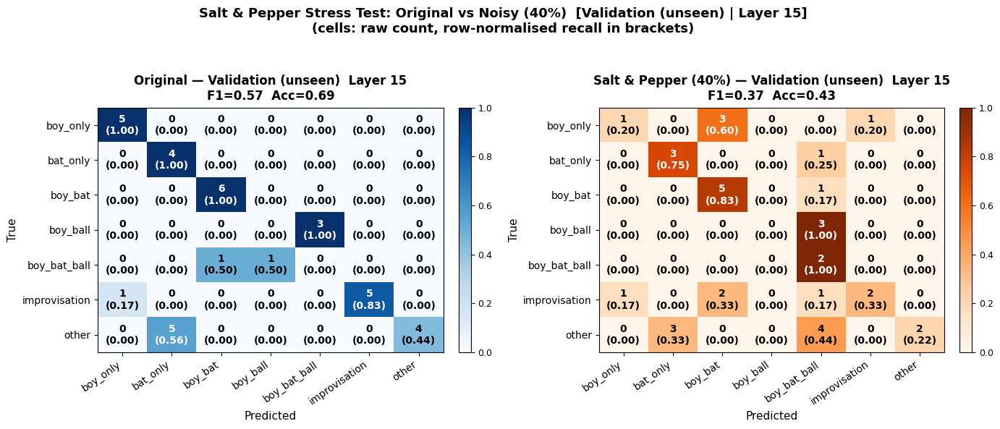

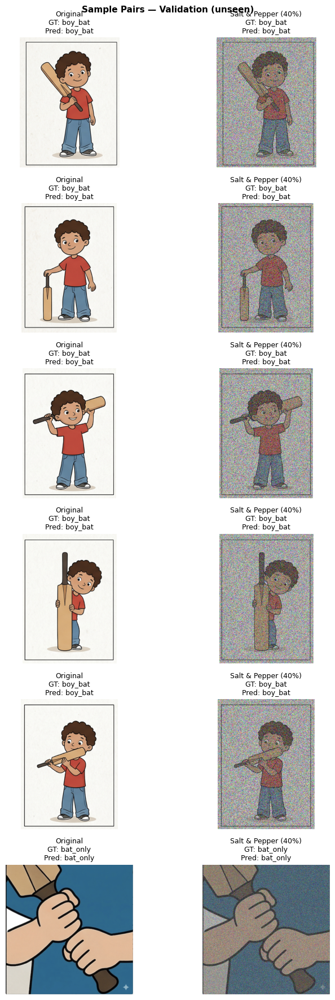

In [ ]:
import torch
import numpy as np
from torchvision import transforms
import joblib
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
from PIL import Image

def apply_salt_and_pepper(img, amount=0.20):
    """
    Applies salt and pepper noise to a PIL image.
    amount: Percentage of pixels to replace with noise (0.05 = 5%)
    """
    img_array = np.array(img).copy()
    # Number of salt/pepper pixels
    num_salt = np.ceil(amount * img_array.size * 0.8)
    num_pepper = np.ceil(amount * img_array.size * 0.8)

    # Add Salt (white pixels)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in img_array.shape]
    img_array[tuple(coords)] = 255

    # Add Pepper (black pixels)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in img_array.shape]
    img_array[tuple(coords)] = 0

    return Image.fromarray(img_array)

# =============================================================================
# SALT & PEPPER STRESS TEST WITH CONFUSION MATRICES — TEST DATASET ONLY
# Side-by-side CMs (original vs noisy), per-class accuracy comparison,
# and summary. Reuses row-normalised CM style.
# =============================================================================

def run_salt_and_pepper_stress_test_with_cm(model, metadata, layer_idx, probe_file,
                                             noise_amount=0.08, dataset_label='Test'):
    """
    Salt-and-pepper stress test on the test dataset with:
      - Side-by-side confusion matrices (original vs noisy)
      - Per-class accuracy comparison table
      - Overall accuracy / macro F1 summary
    """
    model.eval()

    saved  = joblib.load(probe_file)
    clf    = saved['clf']
    scaler = saved['scaler']

    original_preds = []
    noisy_preds    = []
    ground_truth   = []
    sample_images  = []

    print(f"\n[{dataset_label}] Salt & Pepper Test (Noise={noise_amount*100:.0f}%) — "
          f"Layer {layer_idx} | {len(metadata)} samples")

    with torch.no_grad():
        for i, item in enumerate(metadata):
            img   = item.get('pil_img') or get_image(item['source_id'])
            label = item['label']
            ground_truth.append(label)

            # --- Path A: Original ---
            inp_orig  = prep_input(image=[img], text="How many objects are present?")
            out_orig  = model.llama.model(inputs_embeds=inp_orig,
                                               output_hidden_states=True)
            feat_orig = out_orig.hidden_states[layer_idx][0, -1, :].cpu().float().numpy()
            pred_orig = clf.predict(scaler.transform(feat_orig.reshape(1, -1)))[0]
            original_preds.append(pred_orig)

            # --- Path B: Salt & Pepper Noisy ---
            img_noisy  = apply_salt_and_pepper(img, amount=noise_amount)
            inp_noisy  = prep_input(image=[img_noisy], text="How many objects are present?")
            out_noisy  = model.llama.model(inputs_embeds=inp_noisy,
                                                output_hidden_states=True)
            feat_noisy = out_noisy.hidden_states[layer_idx][0, -1, :].cpu().float().numpy()
            pred_noisy = clf.predict(scaler.transform(feat_noisy.reshape(1, -1)))[0]
            noisy_preds.append(pred_noisy)

            if i < 6:
                sample_images.append({
                    'orig_img': img, 'noisy_img': img_noisy,
                    'gt': label, 'orig_pred': pred_orig, 'noisy_pred': pred_noisy,
                })

    ground_truth   = np.array(ground_truth)
    original_preds = np.array(original_preds)
    noisy_preds    = np.array(noisy_preds)

    # ── Overall metrics ───────────────────────────────────────────────────────
    acc_orig  = accuracy_score(ground_truth, original_preds)
    acc_noisy = accuracy_score(ground_truth, noisy_preds)
    f1_orig   = f1_score(ground_truth, original_preds, average='macro', zero_division=0)
    f1_noisy  = f1_score(ground_truth, noisy_preds,    average='macro', zero_division=0)
    drop_acc  = (acc_orig - acc_noisy) / acc_orig * 100 if acc_orig > 0 else 0.0
    drop_f1   = (f1_orig  - f1_noisy)  / f1_orig  * 100 if f1_orig  > 0 else 0.0

    print(f"\n  Overall  —  Original  : Acc={acc_orig:.4f}  Macro F1={f1_orig:.4f}")
    print(f"             Noisy     : Acc={acc_noisy:.4f}  Macro F1={f1_noisy:.4f}")
    print(f"             Acc Drop  : {drop_acc:.2f}%    F1 Drop: {drop_f1:.2f}%")

    # ── Per-class accuracy ────────────────────────────────────────────────────
    present_labels = sorted(set(ground_truth))
    label_names    = [_label_reverse.get(l, str(l)) for l in present_labels]

    print(f"\n  {'Class':<18} {'Orig Acc':>10} {'Noisy Acc':>10} {'Drop':>10}  {'N':>4}")
    print("  " + "-" * 58)
    for lbl, lname in zip(present_labels, label_names):
        mask       = ground_truth == lbl
        n          = mask.sum()
        if n == 0:
            continue
        acc_c_orig  = (original_preds[mask] == lbl).mean()
        acc_c_noisy = (noisy_preds[mask]    == lbl).mean()
        drop_c      = (acc_c_orig - acc_c_noisy) * 100
        flag        = " ◄ large drop" if drop_c > 15 else ""
        print(f"  {lname:<18} {acc_c_orig:>10.4f} {acc_c_noisy:>10.4f} "
              f"{drop_c:>+9.1f}%  {n:>4}{flag}")

    # Full classification reports
    print(f"\n  --- Original Classification Report [{dataset_label}] ---")
    print(classification_report(ground_truth, original_preds,
                                labels=present_labels, target_names=label_names,
                                zero_division=0))
    print(f"  --- Salt & Pepper ({noise_amount*100:.0f}%) Classification Report [{dataset_label}] ---")
    print(classification_report(ground_truth, noisy_preds,
                                labels=present_labels, target_names=label_names,
                                zero_division=0))

    # ── Side-by-side confusion matrices ──────────────────────────────────────
    def _draw_cm(y_true, y_pred, title, ax, cmap):
        present = sorted(set(y_true) | set(y_pred))
        lnames  = [_label_reverse.get(l, str(l)) for l in present]
        cm      = confusion_matrix(y_true, y_pred, labels=present)
        cm_norm = cm.astype(float)
        rs      = cm_norm.sum(axis=1, keepdims=True)
        rs[rs == 0] = 1
        cm_norm /= rs

        im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1, aspect='auto')
        cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cb.ax.tick_params(labelsize=9)

        for i in range(len(present)):
            for j in range(len(present)):
                color = 'white' if cm_norm[i, j] > 0.55 else 'black'
                ax.text(j, i, f'{cm[i, j]}\n({cm_norm[i, j]:.2f})',
                        ha='center', va='center',
                        fontsize=10, fontweight='bold', color=color)

        ax.set_xticks(range(len(present)))
        ax.set_yticks(range(len(present)))
        ax.set_xticklabels(lnames, rotation=35, ha='right', fontsize=10)
        ax.set_yticklabels(lnames, fontsize=10)
        ax.set_xlabel('Predicted', fontsize=11)
        ax.set_ylabel('True',      fontsize=11)
        mf1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
        acc_v = accuracy_score(y_true, y_pred)
        ax.set_title(f'{title}\nF1={mf1:.2f}  Acc={acc_v:.2f}',
                     fontsize=12, fontweight='bold', pad=8)

    fig_cm, axes_cm = plt.subplots(1, 2, figsize=(14, 6))
    _draw_cm(ground_truth, original_preds,
             f'Original — {dataset_label}  Layer {layer_idx}',
             axes_cm[0], cmap='Blues')
    _draw_cm(ground_truth, noisy_preds,
             f'Salt & Pepper ({noise_amount*100:.0f}%) — {dataset_label}  Layer {layer_idx}',
             axes_cm[1], cmap='Oranges')
    fig_cm.suptitle(
        f'Salt & Pepper Stress Test: Original vs Noisy ({noise_amount*100:.0f}%)  '
        f'[{dataset_label} | Layer {layer_idx}]\n'
        '(cells: raw count, row-normalised recall in brackets)',
        fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

    # ── Sample image pairs ────────────────────────────────────────────────────
    if sample_images:
        n_show = len(sample_images)
        fig_s, axes_s = plt.subplots(n_show, 2, figsize=(8, 3 * n_show))
        if n_show == 1:
            axes_s = [axes_s]
        for idx_s, s in enumerate(sample_images):
            axes_s[idx_s][0].imshow(s['orig_img'])
            axes_s[idx_s][0].set_title(
                f"Original\nGT: {_label_reverse.get(s['gt'], s['gt'])}\n"
                f"Pred: {_label_reverse.get(s['orig_pred'], s['orig_pred'])}", fontsize=9)
            axes_s[idx_s][0].axis('off')
            axes_s[idx_s][1].imshow(s['noisy_img'])
            axes_s[idx_s][1].set_title(
                f"Salt & Pepper ({noise_amount*100:.0f}%)\nGT: {_label_reverse.get(s['gt'], s['gt'])}\n"
                f"Pred: {_label_reverse.get(s['noisy_pred'], s['noisy_pred'])}", fontsize=9)
            axes_s[idx_s][1].axis('off')
        fig_s.suptitle(f'Sample Pairs — {dataset_label}', fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.show()

    return {
        'acc_orig':  acc_orig,  'acc_noisy': acc_noisy,
        'f1_orig':   f1_orig,   'f1_noisy':  f1_noisy,
        'original_preds': original_preds,
        'noisy_preds':    noisy_preds,
        'ground_truth':   ground_truth,
    }


# ── Run on test dataset only ──────────────────────────────────────────────────
print("=" * 65)
print("SALT & PEPPER STRESS TEST WITH CM — TEST / VALIDATION DATASET")
print("=" * 65)
snp_results_test = run_salt_and_pepper_stress_test_with_cm(
    model         = phi2_proj_model,
    metadata      = dataset_val_last_text,
    layer_idx     = 15,
    probe_file    = 'saved_probes/last_text_token_layer_15.joblib',
    noise_amount  = 0.4,
    dataset_label = 'Validation (unseen)',
)

VQA CONTEXT STRESS TEST WITH CM — TEST / VALIDATION DATASET

[Validation (unseen)] VQA Context Stress Test — Layer 15 | 35 samples
text is How many objects are present in this image?
text_input <|begin_of_text|>How many objects are present in this image?
image embd tensor([[[-5.8496e-01,  5.4639e-01,  8.5010e-01,  ...,  1.7188e+00,
           3.4058e-01,  6.6406e-01],
         [-1.5303e+00,  1.0137e+00,  1.8945e+00,  ...,  3.9111e-01,
          -1.0635e+00, -7.7490e-01],
         [-9.0381e-01,  6.6101e-02,  5.5127e-01,  ...,  1.4209e+00,
           9.2041e-01,  1.0811e+00],
         ...,
         [ 1.1719e-02,  4.8096e-02,  2.9907e-02,  ...,  1.2634e-02,
          -3.2471e-02,  1.9775e-02],
         [ 4.0894e-03, -1.2512e-02,  3.0518e-02,  ...,  1.5869e-02,
          -4.4678e-02,  2.8076e-02],
         [-2.3315e-02,  1.0788e-05,  4.4922e-02,  ..., -2.1606e-02,
          -1.3062e-02,  2.0508e-02]]], device='cuda:0', dtype=torch.float16)
text embd tensor([[[ 0.0028,  0.0033, -0.0099,  ..

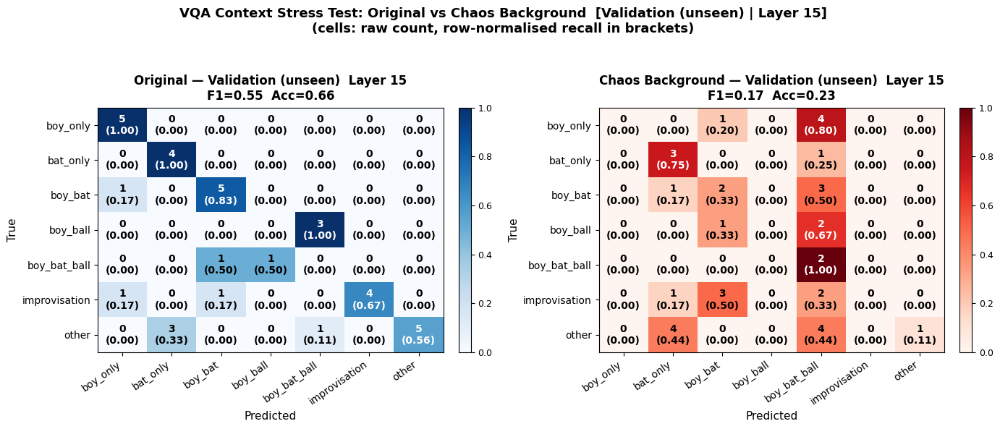

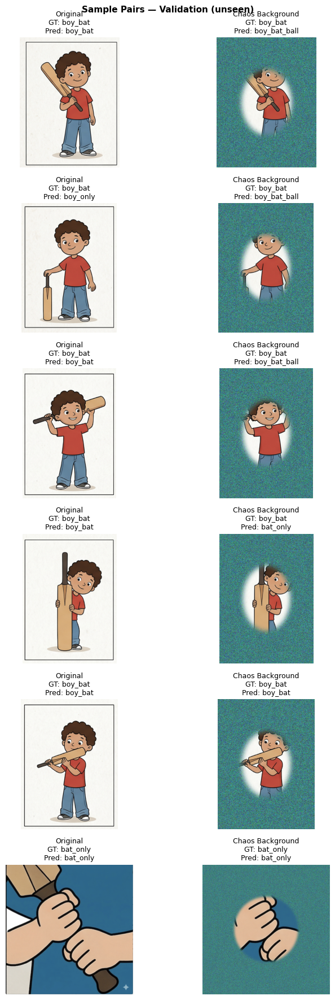

In [ ]:
import torch
import numpy as np
from PIL import Image, ImageDraw, ImageFilter
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

def apply_extreme_distraction(img):
    """
    Creates a chaotic, high-entropy background and blends the central object into it.
    """
    w, h = img.size

    # 1. Create Chaos Background (Colored Noise)
    noise_array = np.random.randint(0, 255, (h, w, 3), dtype=np.uint8)
    # Shift noise to be 'field-like' (greenish-brown) to make it harder
    noise_array[:, :, 0] //= 2  # Reduce Red
    bg = Image.fromarray(noise_array)

    # 2. Create a Blurred Circular Mask for the object
    mask = Image.new('L', (w, h), 0)
    draw = ImageDraw.Draw(mask)

    # Coordinates for the 'safe zone' (30% to 70% of image)
    x0, y0 = w * 0.25, h * 0.25
    x1, y1 = w * 0.75, h * 0.75
    draw.ellipse([x0, y0, x1, y1], fill=255)

    # Feather the edges so the model doesn't just look for a sharp crop line
    mask = mask.filter(ImageFilter.GaussianBlur(radius=15))

    # 3. Composite
    return Image.composite(img, bg, mask)
# =============================================================================
# VQA CONTEXT STRESS TEST WITH CONFUSION MATRICES — TEST DATASET ONLY
# Side-by-side CMs (original vs chaotic-background), per-class accuracy
# comparison, and summary. Uses the same probe-based prediction path so
# results are directly comparable to the other stress tests.
# =============================================================================

def run_vqa_context_stress_test_with_cm(model, metadata, tokenizer,
                                         layer_idx=15, probe_file=None,
                                         dataset_label='Test'):
    """
    Extreme-distraction (chaos-background) stress test on the test dataset with:
      - Side-by-side confusion matrices (original vs distracted)
      - Per-class accuracy comparison table
      - Overall accuracy / macro F1 summary
    Uses the probe (not raw generation) for a fair comparison with other tests.
    """
    model.eval()

    saved  = joblib.load(probe_file)
    clf    = saved['clf']
    scaler = saved['scaler']

    original_preds   = []
    distracted_preds = []
    ground_truth     = []
    sample_images    = []

    print(f"\n[{dataset_label}] VQA Context Stress Test — Layer {layer_idx} | "
          f"{len(metadata)} samples")

    with torch.no_grad():
        for i, item in enumerate(metadata):
            img   = item.get('pil_img') or get_image(item['source_id'])
            label = item['label']
            ground_truth.append(label)

            # --- Path A: Original ---
            inp_orig  = prep_input(image=[img], text="How many objects are present in this image?")
            out_orig  = model.llama.model(inputs_embeds=inp_orig,
                                               output_hidden_states=True)
            feat_orig = out_orig.hidden_states[layer_idx][0, -1, :].cpu().float().numpy()
            pred_orig = clf.predict(scaler.transform(feat_orig.reshape(1, -1)))[0]
            original_preds.append(pred_orig)

            # --- Path B: Chaotic Background ---
            img_dist  = apply_extreme_distraction(img)
            inp_dist  = prep_input(image=[img_dist], text="How many objects are present in this image?")
            out_dist  = model.llama.model(inputs_embeds=inp_dist,
                                               output_hidden_states=True)
            feat_dist = out_dist.hidden_states[layer_idx][0, -1, :].cpu().float().numpy()
            pred_dist = clf.predict(scaler.transform(feat_dist.reshape(1, -1)))[0]
            distracted_preds.append(pred_dist)

            if i < 6:
                sample_images.append({
                    'orig_img': img, 'dist_img': img_dist,
                    'gt': label, 'orig_pred': pred_orig, 'dist_pred': pred_dist,
                })

    ground_truth     = np.array(ground_truth)
    original_preds   = np.array(original_preds)
    distracted_preds = np.array(distracted_preds)

    # ── Overall metrics ───────────────────────────────────────────────────────
    acc_orig = accuracy_score(ground_truth, original_preds)
    acc_dist = accuracy_score(ground_truth, distracted_preds)
    f1_orig  = f1_score(ground_truth, original_preds,   average='macro', zero_division=0)
    f1_dist  = f1_score(ground_truth, distracted_preds, average='macro', zero_division=0)
    drop_acc = (acc_orig - acc_dist) / acc_orig * 100 if acc_orig > 0 else 0.0
    drop_f1  = (f1_orig  - f1_dist)  / f1_orig  * 100 if f1_orig  > 0 else 0.0

    print(f"\n  Overall  —  Original   : Acc={acc_orig:.4f}  Macro F1={f1_orig:.4f}")
    print(f"             Distracted : Acc={acc_dist:.4f}  Macro F1={f1_dist:.4f}")
    print(f"             Acc Drop   : {drop_acc:.2f}%    F1 Drop: {drop_f1:.2f}%")

    # ── Per-class accuracy ────────────────────────────────────────────────────
    present_labels = sorted(set(ground_truth))
    label_names    = [_label_reverse.get(l, str(l)) for l in present_labels]

    print(f"\n  {'Class':<18} {'Orig Acc':>10} {'Dist Acc':>10} {'Drop':>10}  {'N':>4}")
    print("  " + "-" * 58)
    for lbl, lname in zip(present_labels, label_names):
        mask       = ground_truth == lbl
        n          = mask.sum()
        if n == 0:
            continue
        acc_c_orig = (original_preds[mask]   == lbl).mean()
        acc_c_dist = (distracted_preds[mask] == lbl).mean()
        drop_c     = (acc_c_orig - acc_c_dist) * 100
        flag       = " ◄ large drop" if drop_c > 15 else ""
        print(f"  {lname:<18} {acc_c_orig:>10.4f} {acc_c_dist:>10.4f} "
              f"{drop_c:>+9.1f}%  {n:>4}{flag}")

    # Full classification reports
    print(f"\n  --- Original Classification Report [{dataset_label}] ---")
    print(classification_report(ground_truth, original_preds,
                                labels=present_labels, target_names=label_names,
                                zero_division=0))
    print(f"  --- Distracted (Chaos BG) Classification Report [{dataset_label}] ---")
    print(classification_report(ground_truth, distracted_preds,
                                labels=present_labels, target_names=label_names,
                                zero_division=0))

    # ── Side-by-side confusion matrices ──────────────────────────────────────
    def _draw_cm(y_true, y_pred, title, ax, cmap):
        present = sorted(set(y_true) | set(y_pred))
        lnames  = [_label_reverse.get(l, str(l)) for l in present]
        cm      = confusion_matrix(y_true, y_pred, labels=present)
        cm_norm = cm.astype(float)
        rs      = cm_norm.sum(axis=1, keepdims=True)
        rs[rs == 0] = 1
        cm_norm /= rs

        im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1, aspect='auto')
        cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cb.ax.tick_params(labelsize=9)

        for i in range(len(present)):
            for j in range(len(present)):
                color = 'white' if cm_norm[i, j] > 0.55 else 'black'
                ax.text(j, i, f'{cm[i, j]}\n({cm_norm[i, j]:.2f})',
                        ha='center', va='center',
                        fontsize=10, fontweight='bold', color=color)

        ax.set_xticks(range(len(present)))
        ax.set_yticks(range(len(present)))
        ax.set_xticklabels(lnames, rotation=35, ha='right', fontsize=10)
        ax.set_yticklabels(lnames, fontsize=10)
        ax.set_xlabel('Predicted', fontsize=11)
        ax.set_ylabel('True',      fontsize=11)
        mf1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
        acc_v = accuracy_score(y_true, y_pred)
        ax.set_title(f'{title}\nF1={mf1:.2f}  Acc={acc_v:.2f}',
                     fontsize=12, fontweight='bold', pad=8)

    fig_cm, axes_cm = plt.subplots(1, 2, figsize=(14, 6))
    _draw_cm(ground_truth, original_preds,
             f'Original — {dataset_label}  Layer {layer_idx}',
             axes_cm[0], cmap='Blues')
    _draw_cm(ground_truth, distracted_preds,
             f'Chaos Background — {dataset_label}  Layer {layer_idx}',
             axes_cm[1], cmap='Reds')
    fig_cm.suptitle(
        f'VQA Context Stress Test: Original vs Chaos Background  '
        f'[{dataset_label} | Layer {layer_idx}]\n'
        '(cells: raw count, row-normalised recall in brackets)',
        fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

    # ── Sample image pairs ────────────────────────────────────────────────────
    if sample_images:
        n_show = len(sample_images)
        fig_s, axes_s = plt.subplots(n_show, 2, figsize=(8, 3 * n_show))
        if n_show == 1:
            axes_s = [axes_s]
        for idx_s, s in enumerate(sample_images):
            axes_s[idx_s][0].imshow(s['orig_img'])
            axes_s[idx_s][0].set_title(
                f"Original\nGT: {_label_reverse.get(s['gt'], s['gt'])}\n"
                f"Pred: {_label_reverse.get(s['orig_pred'], s['orig_pred'])}", fontsize=9)
            axes_s[idx_s][0].axis('off')
            axes_s[idx_s][1].imshow(s['dist_img'])
            axes_s[idx_s][1].set_title(
                f"Chaos Background\nGT: {_label_reverse.get(s['gt'], s['gt'])}\n"
                f"Pred: {_label_reverse.get(s['dist_pred'], s['dist_pred'])}", fontsize=9)
            axes_s[idx_s][1].axis('off')
        fig_s.suptitle(f'Sample Pairs — {dataset_label}', fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.show()

    return {
        'acc_orig': acc_orig, 'acc_dist': acc_dist,
        'f1_orig':  f1_orig,  'f1_dist':  f1_dist,
        'original_preds':   original_preds,
        'distracted_preds': distracted_preds,
        'ground_truth':     ground_truth,
    }


# ── Run on test dataset only ──────────────────────────────────────────────────
print("=" * 65)
print("VQA CONTEXT STRESS TEST WITH CM — TEST / VALIDATION DATASET")
print("=" * 65)
vqa_context_results_test = run_vqa_context_stress_test_with_cm(
    model         = phi2_proj_model,
    metadata      = dataset_val_last_text,
    tokenizer     = tokenizer,
    layer_idx     = 15,
    probe_file    = 'saved_probes/last_text_token_layer_15.joblib',
    dataset_label = 'Validation (unseen)',
)


# Layer Group Analyis

In [ ]:

import os
import gc
import json
import torch
import torch.nn as nn
from torch.nn import functional as F
import re
import random
import numpy as np
from PIL import Image
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, DataCollatorWithPadding, AutoProcessor
from transformers import CLIPVisionModel, CLIPImageProcessor, CLIPVisionConfig
import peft
from peft import LoraConfig
from peft import PeftModel
import requests
from io import BytesIO


adapter_path="trained_phi2_gpt_model_new"
merged_phi2 = peft.PeftModel.from_pretrained(llama, adapter_path)


tokenizer.pad_token = tokenizer.eos_token
bos_token_id = tokenizer.bos_token_id
pad_token_id = tokenizer.pad_token_id
eos_token_id = tokenizer.eos_token_id

eoc_string = 'caption image:'
eoc_tokens = tokenizer.encode(eoc_string)
print(f'eoc_tokens : {eoc_tokens}')

eoq_string = 'end of question:'
eoq_tokens = tokenizer.encode(eoq_string)
print(f'eoq_tokens : {eoq_tokens}')

print(bos_token_id, pad_token_id, eos_token_id)
print(tokenizer.decode([50256, 50256, 50256]))
print('eoc tokens decoded:', tokenizer.decode(eoc_tokens))
print('eoq tokens decoded:', tokenizer.decode(eoq_tokens))
print(len(tokenizer))

eoc_tokens : [128000, 24232, 2217, 25]
eoq_tokens : [128000, 408, 315, 3488, 25]
128000 128001 128001
parableparableparable
eoc tokens decoded: <|begin_of_text|>caption image:
eoq tokens decoded: <|begin_of_text|>end of question:
128256


In [ ]:
class ClipProjectionBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.pre_norm = nn.LayerNorm(channels)

        self.proj = nn.Sequential(
            nn.Linear(channels, channels), # Changed from channels * 2
            nn.GELU(),
            nn.Linear(channels, channels)
        )
    def forward(self, x):
        x = self.pre_norm(x)
        return x + self.proj(x)

class Phi2ProjModel(nn.Module):
    def __init__(self, clip_model, clip_processor, proj_model, llama, clip_embed_dim=2304, phi2_dim=2048):
        super(Phi2ProjModel, self).__init__()
        self.clip_embed_dim = clip_embed_dim
        self.phi2_dim = phi2_dim
        self.proj_lin_layer = nn.Linear(clip_embed_dim, phi2_dim)
        self.clip_model = clip_model
        self.clip_processor = clip_processor
        self.proj_model = proj_model
        self.llama = llama

    def forward(self, input_embed):
        max_len = 60
        print("shape of input_embed",input_embed.shape)
        output = self.llama.generate(inputs_embeds=input_embed,
                                          max_new_tokens=max_len,
                                          num_beams=5,             # Look at the top 5 possible sequences
                                          early_stopping=True,     # Stop when the best path is found
                                          do_sample=False,         # Keep it deterministic
                                          return_dict_in_generate = True,
                                          output_hidden_states=True,
                                          bos_token_id=bos_token_id,
                                          pad_token_id=bos_token_id,
                                          eos_token_id=bos_token_id)

        return output


projection_layer = ClipProjectionBlock(2048).to(device)

phi2_proj_model = Phi2ProjModel(clip_model, clip_processor, projection_layer, merged_phi2).to(device)

In [ ]:
phi2_proj_model.proj_lin_layer.load_state_dict(torch.load('phi2_proj_projm_2_load.pth'))
phi2_proj_model.proj_model.load_state_dict(torch.load('phi2_proj_model_2_load.pth'))


<All keys matched successfully>

In [ ]:

def prepare_input_embed(img=None, audio=None, text=None, extra=None):

    input_embed_exists = 0

    inputs_given = []

    if img is not None:
        inputs = clip_processor(images=img, return_tensors="pt").to(device)
        clip_output = clip_model(**inputs, output_hidden_states=True)  # B, 50, 768
        clip_embeddings = combine_features(clip_output)     # B, 49, 768
        image_embed = phi2_proj_model.proj_lin_layer(clip_embeddings)   # B, 49, 2560
        image_embed = phi2_proj_model.proj_model(image_embed)    # B, 49, 2560
        B, _, C = image_embed.shape
        eoc_tkn_tensor = torch.tensor(eoc_tokens, dtype=torch.int64).to(device)  # [4] -> EOI token matrix
        eoc_tensor = eoc_tkn_tensor.repeat(B, 1)  # [B, 4]
        eoc_embed = phi2_proj_model.llama.model.model.embed_tokens(eoc_tensor)  # B, 4, 2560 -> EOI embeddings (torch.float32)

        input_image_embed  = torch.cat([image_embed, eoc_embed], dim=1)  #B, 53, 2560 -> Adding EOI embeddings to indicate end of image
        input_image_embed = input_image_embed.to(dtype=torch.float16)
        print("image embd",input_image_embed)

    if text is not None:
        text_tkn_tensor = torch.tensor(text, dtype=torch.int64).to(device)  # [4] -> EOI token matrix
        text_tkn_tensor = text_tkn_tensor.unsqueeze(0)
        text_embed = phi2_proj_model.llama.model.model.embed_tokens(text_tkn_tensor)
        print("text embd",text_embed)

    if extra is not None:
        extra_tkn_tensor = torch.tensor(extra, dtype=torch.int64).to(device)  # [4] -> EOI token matrix
        extra_tkn_tensor = extra_tkn_tensor.unsqueeze(0)
        extra_embed = phi2_proj_model.llama.model.model.embed_tokens(extra_tkn_tensor)
        print("extra embd",extra_embed)


    # If image is present, it gets 1st place in input_embed
    if img is not None:
        input_embed = input_image_embed
        input_embed_exists = 1

    if text:
        # If input_embed is already present, that means image/audio are present. So, append text_embed to it
        if input_embed_exists:
            if audio is not None:
                input_embed = torch.cat([input_embed, text_embed], dim=1)
            else:
                input_embed = torch.cat([input_embed, text_embed], dim=1)
        # If input_embed is not there, that means neither image not audio there. So, give text_embed as input_embed
        else:
            input_embed = text_embed
            input_embed_exists = 1
        inputs_given.append(text)

    inputs_given.append(eoq_tokens)

    print("input given is " , inputs_given)

    eoq_tkn_tensor = torch.tensor(eoq_tokens, dtype=torch.int64).to(device)  # [4] -> EOI token matrix
    B = 1
    eoq_tensor = eoq_tkn_tensor.repeat(B, 1)  # [B, 4]
    eoq_embed = phi2_proj_model.llama.model.model.embed_tokens(eoq_tensor)  # B, 4, 2560 -> EOI embeddings (torch.float32)

    input_embed  = torch.cat([input_embed, eoq_embed,extra_embed], dim=1)
    # else:
    # input_embed  = torch.cat([input_embed, eoq_embed], dim=1)
    print("final input embd",input_embed)

    print("--- Input Sequence Breakdown ---")

# 1. Decode the End Of Caption tokens
    print(f"Image Marker: {tokenizer.decode(eoc_tokens)}")



# 2. Decode the actual question text tokens
# Assuming 'text_tokens' is the variable used in your gradio/inference function

    print(f"Question Text: {tokenizer.decode(text)}")

# 3. Decode the End Of Question tokens
    print(f"Question Closer: {tokenizer.decode(eoq_tokens)}")

    print("\n--- Full Combined String ---")
# This is the 'Text' equivalent of the sequence in final_input_embed
    full_string = tokenizer.decode(eoc_tokens) + tokenizer.decode(text) + tokenizer.decode(eoq_tokens)
    print(full_string)
    return input_embed

# **Experiment 1 - Does Multi-Layer Fusion Improve in Cross-Modal Visual Grounding Analysis?**

In [ ]:
#vision mapping analysis


═════════════════════════════════════════════════════════════════════════════════════════════════════════
  Extracting Input Attribution Saliency Maps ── Dense Connector Model (Static)
  Target Subplot Group : COUNTING CATEGORIES ONLY (dataset size: 234)
═════════════════════════════════════════════════════════════════════════════════════════════════════════


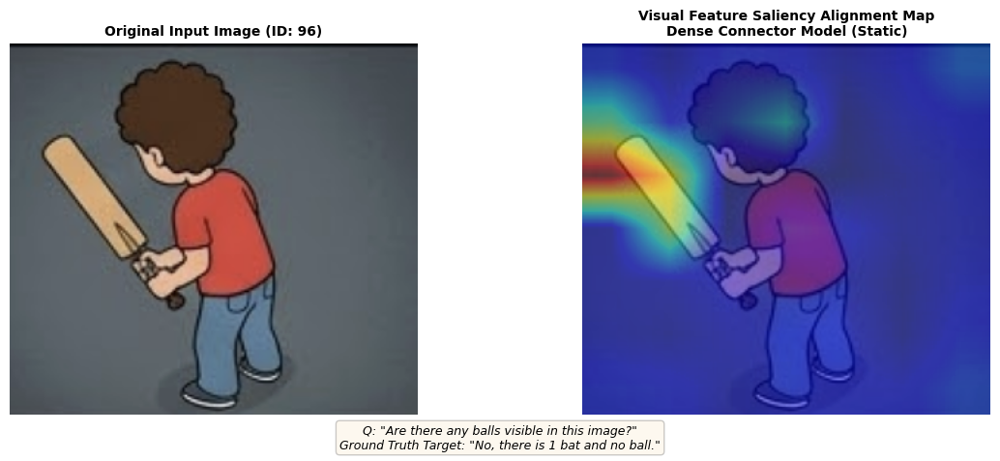

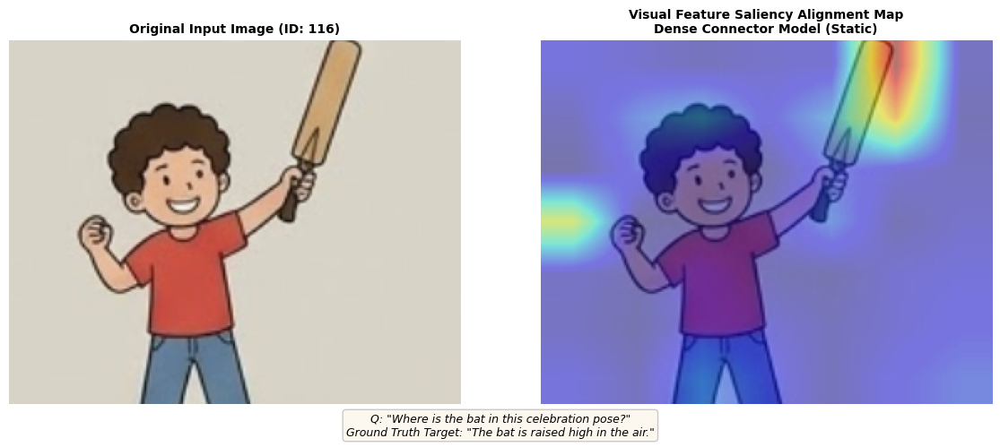

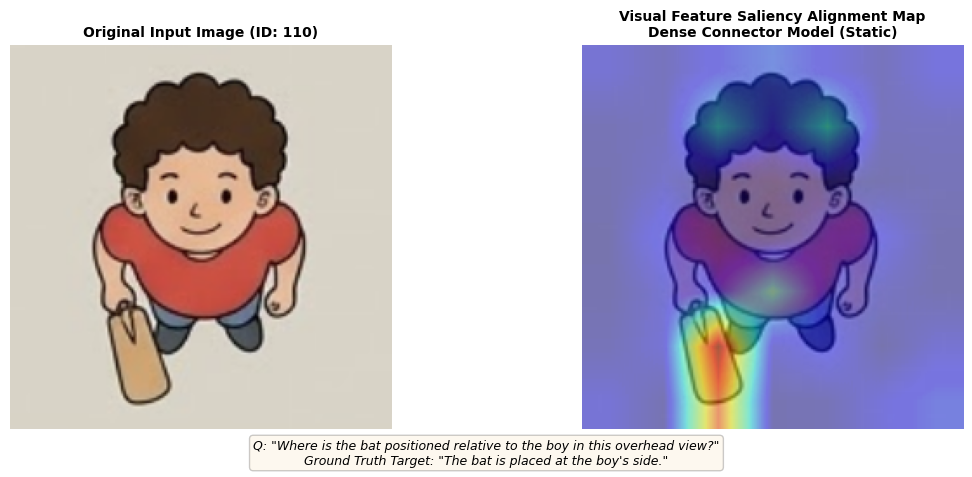

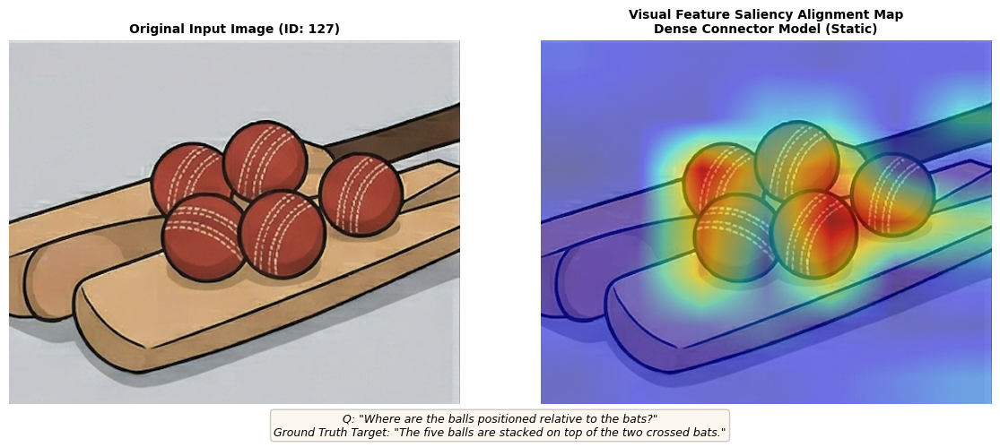

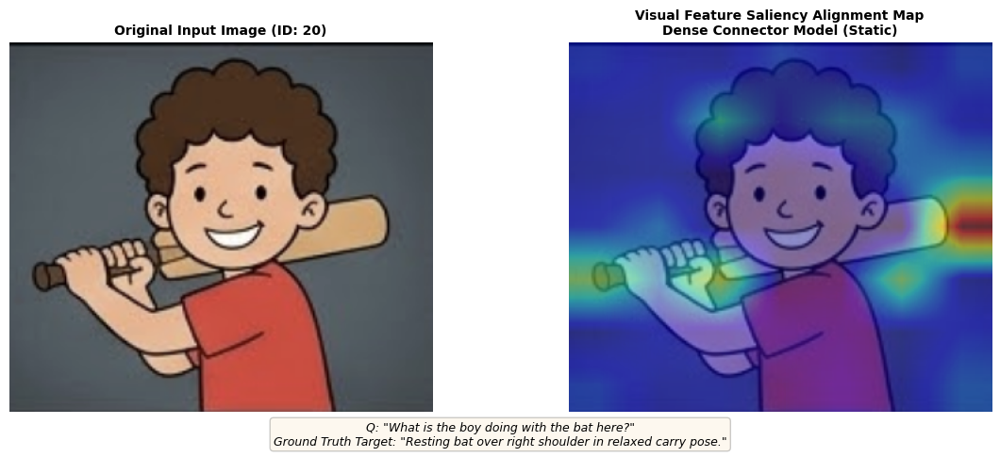

In [ ]:
def visualize_visual_saliency_alignment_maps(model, tokenizer, n_images=5, save_path=None):
    """
    Approach 4 — Visual Feature Saliency Alignment Map (Gradient Attribution).
    Streamlined exclusively for the 'counting' category. Computes the absolute gradients
    of the answer cross-entropy loss with respect to the 49 image patch tokens.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import torch
    import torch.nn.functional as F
    from PIL import Image

    # Ensure gradients are tracked for attribution calculation
    torch.set_grad_enabled(True)
    model.train() # Set to train mode locally to unlock embedding gradient tracking

    # Detect architecture type
    is_tgif = hasattr(model, 'tgif_router')
    model_label = "TGIF Model (Adaptive)" if is_tgif else "Dense Connector Model (Static)"

    # ── ① Automated Counting Dataset Filtering ──
    # Since only the counting category is used, gather all unique keys directly
    sample_pool_ids = sorted([
        img_id for img_id in instruct150k_images.keys()
        if instruct150k_qa.get(img_id) is not None
    ])

    # Reproducible sampling using a fixed torch seed
    rng = torch.Generator()
    rng.manual_seed(42)
    perm = torch.randperm(len(sample_pool_ids), generator=rng).tolist()
    sample_ids = [sample_pool_ids[i] for i in perm[:n_images]]

    # ── ② Shared Dense Feature Grouping Helper ──
    def _combine_features_dense(hs):
        early = torch.stack(hs[0:6], dim=0).sum(dim=0) / 6
        late = torch.stack(hs[6:12], dim=0).sum(dim=0) / 6
        final = hs[12]
        return torch.cat([final, early, late], dim=-1)

    print(f'\n{"═"*105}')
    print(f'  Extracting Input Attribution Saliency Maps ── {model_label}')
    print(f'  Target Subplot Group : COUNTING CATEGORIES ONLY (dataset size: {len(sample_pool_ids)})')
    print(f'{"═"*105}')

    for img_id in sample_ids:
        qa = instruct150k_qa.get(img_id)
        _, qn_text, ans_text = qa
        if not qn_text or not ans_text: continue

        # Vector conversion using device allocation
        qn_toks = tokenizer(qn_text, return_tensors='pt', truncation=True, max_length=32)['input_ids'].to(device)
        ans_toks = tokenizer(ans_text, return_tensors='pt', truncation=True, max_length=16)['input_ids'].to(device)
        pil_img = get_image(img_id)

        # --- Extract CLIP Features & Build Embeddings ---
        inputs = model.clip_processor(images=pil_img, return_tensors='pt').to(device)
        clip_out = model.clip_model(**inputs, output_hidden_states=True)

        if is_tgif:
            layer_hs = [clip_out.hidden_states[l][:, 1:, :].float() for l in range(1, 13)]
            layer_hs_tensor = torch.stack(layer_hs, dim=1)
            qn_text_embeds = model.llama.model.model.embed_tokens(qn_toks)
            f_text = qn_text_embeds.mean(dim=1)
            layer_weights = model.tgif_router(f_text)
            clip_embeddings = tgif_fuse_layers(layer_hs_tensor, layer_weights)
        else:
            hidden_states_list = [clip_out.hidden_states[i][:, 1:, :].float() for i in range(13)]
            clip_embeddings = _combine_features_dense(hidden_states_list)

        # Project tokens to standard LLM dimensions
        image_embed = model.proj_lin_layer(clip_embeddings)
        image_embed = model.proj_model(image_embed)

        # CRITICAL STEP: Detach and isolate image features to harvest clean gradients
        image_embed = image_embed.clone().detach().requires_grad_(True)

        # Build sequence token components
        eoi_emb = model.llama.model.model.embed_tokens(eoi_tkn_tensor.unsqueeze(0))
        eoq_emb = model.llama.model.model.embed_tokens(eoq_tkn_tensor.unsqueeze(0))
        qn_emb = model.llama.model.model.embed_tokens(qn_toks)
        ans_emb = model.llama.model.model.embed_tokens(ans_toks)

        ctx = torch.cat([image_embed, eoi_emb, qn_emb, eoq_emb, ans_emb], dim=1).to(dtype=torch.float16)

        # --- Forward Pass for Loss Generation ---
        out = model.llama.forward(inputs_embeds=ctx)

        n_img = image_embed.shape[1] # 49 patches
        Q_ = qn_toks.shape[-1]
        T_ = ans_toks.shape[-1]
        ans_start = n_img + eoi_tkn_tensor.shape[0] + Q_ + eoq_tkn_tensor.shape[0]

        # Causal token prediction window alignment
        pred = out.logits[:, ans_start - 1 : ans_start + T_ - 1, :].float()
        if pred.shape[1] < T_: continue

        # Compute cross-entropy loss against ground truth target answer strings
        loss = F.cross_entropy(pred.reshape(T_, pred.shape[-1]), ans_toks.reshape(T_))

        # --- Backward Pass for Sensitivity Attribution ---
        model.zero_grad()
        loss.backward()

        # Isolate absolute gradient vectors accumulated at the 49 visual patch positions
        patch_gradients = image_embed.grad.squeeze(0).abs().sum(dim=-1).cpu().numpy()

        # Normalize gradients between 0 and 1 for heatmap visualization
        if patch_gradients.max() > 0:
            patch_gradients = patch_gradients / patch_gradients.max()

        # Reshape 1D array of 49 elements into the 7x7 spatial grid matrix
        heatmap_7x7 = patch_gradients.reshape(7, 7)

        # --- Rendering Side-by-Side Analytics Plots ───
        fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=100)

        # Left: Source Image
        axes[0].imshow(pil_img)
        axes[0].set_title(f"Original Input Image (ID: {img_id})", fontsize=10, fontweight='bold')
        axes[0].axis('off')

        # Right: Gradient Sensitivity Overlay
        axes[1].imshow(pil_img)

        # Interpolate 7x7 matrix onto original image resolution footprint
        heatmap_resized = Image.fromarray((heatmap_7x7 * 255).astype(np.uint8)).resize(pil_img.size, resample=Image.Resampling.BILINEAR)

        im_h = axes[1].imshow(heatmap_resized, cmap='jet', alpha=0.45)
        axes[1].set_title(f"Visual Feature Saliency Alignment Map\n{model_label}", fontsize=10, fontweight='bold')
        axes[1].axis('off')

        fig.text(0.5, 0.01, f"Q: \"{qn_text}\"\nGround Truth Target: \"{ans_text}\"",
                 ha='center', fontsize=9, style='italic', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.2))

        plt.tight_layout(rect=[0, 0.05, 1, 0.95])

        if save_path:
            specific_path = f"saliency_counting_id_{img_id}_{save_path}"
            plt.savefig(specific_path, bbox_inches='tight')

        plt.show()

    # Revert model states cleanly back to default evaluation format
    model.eval()
    torch.set_grad_enabled(False)


visualize_visual_saliency_alignment_maps(phi2_proj_model, tokenizer)

# **Experiment - 2 Visual Representation Ablation Study**


═══════════════════════════════════════════════════════════════════════════
  RUNNING LATENT NOISE INJECTION PROVING GROUND ANALYSIS
  Target Intervention: FINAL LAYER TENSOR CORRUPTION (Noise Std=2.0)
═══════════════════════════════════════════════════════════════════════════



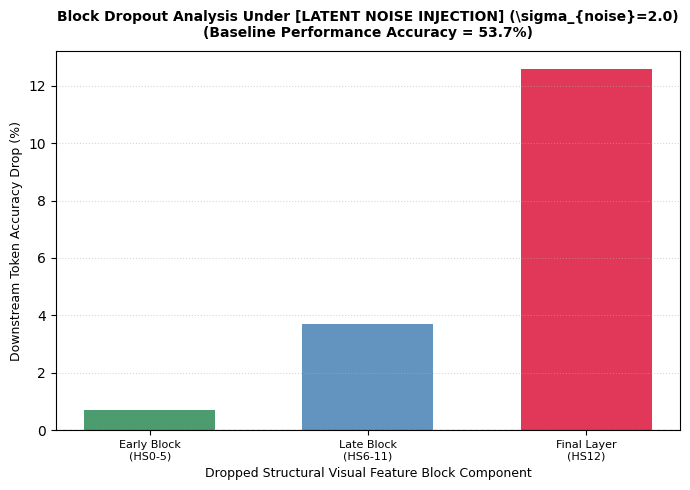

[0.007023434924042782, 0.03703947054303214, 0.1258344338639923]

In [ ]:
def eval_group_dropout_latent_noise_proving_ground(model, tokenizer, n_images=230, noise_std=1.0):
    """
    Approach 2 — Group-wise Dropout Token-Accuracy Ablation via Latent Vector Corruption.
    Injects Gaussian noise directly into the final_layer tensor prior to the
    projection layer to force reliance onto early and late block pathways.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import torch

    NUM_GROUPS = 3
    NUM_CLIP_HS = 13
    model.eval()

    group_labels = ['Early Block\n(HS0-5)', 'Late Block\n(HS6-11)', 'Final Layer\n(HS12)']

    # Dynamic unwrapper loops to extract the leaf embedding layer regardless of PEFT depth
    base_llm = model.llama
    while hasattr(base_llm, "model"):
        base_llm = base_llm.model
    embed_tokens_layer = base_llm.embed_tokens

    # Isolate counting pool
    sample_pool_ids = sorted([img_id for img_id in instruct150k_images.keys() if instruct150k_qa.get(img_id) is not None])
    rng = torch.Generator().manual_seed(42)
    perm = torch.randperm(len(sample_pool_ids), generator=rng).tolist()
    sample_ids = [sample_pool_ids[i] for i in perm[:n_images]]

    print(f'\n{"═"*75}')
    print(f'  RUNNING LATENT NOISE INJECTION PROVING GROUND ANALYSIS')
    print(f'  Target Intervention: FINAL LAYER TENSOR CORRUPTION (Noise Std={noise_std})')
    print(f'{"═"*75}\n')

    # Modified feature fusion that applies latent space noise
    def _combine_features_block_dropout(hs, g_abl, noise_std_val):
        early_block = torch.stack(hs[0:6], dim=0).sum(dim=0) / 6
        late_block  = torch.stack(hs[6:12], dim=0).sum(dim=0) / 6
        final_layer = hs[12]

        # Inject targeted latent noise
        if noise_std_val > 0.0:
            # Match the device and precision of the incoming hidden state tensor
            noise = torch.randn_like(final_layer, device=final_layer.device, dtype=final_layer.dtype) * noise_std_val
            final_layer = final_layer + noise

        # Apply ablation masks
        if g_abl == 0: early_block = torch.zeros_like(early_block)
        elif g_abl == 1: late_block = torch.zeros_like(late_block)
        elif g_abl == 2: final_layer = torch.zeros_like(final_layer)

        return torch.cat([final_layer, early_block, late_block], dim=-1)

    def _fuse_loss_dense_accuracy(hs, qn_toks, ans_toks, g_abl=None):
        # Route both the baseline and the ablated sequences through the noisy generation function
        if g_abl is not None:
            combined = _combine_features_block_dropout(hs, g_abl, noise_std)
        else:
            # FIXED: Changed keyword argument name to match parameter (noise_std_val)
            combined = _combine_features_block_dropout(hs, g_abl=None, noise_std_val=noise_std)

        image_embed = model.proj_model(model.proj_lin_layer(combined))
        ctx = torch.cat([image_embed, embed_tokens_layer(eoi_tkn_tensor.unsqueeze(0)), embed_tokens_layer(qn_toks),
                         embed_tokens_layer(eoq_tkn_tensor.unsqueeze(0)), embed_tokens_layer(ans_toks)], dim=1).to(dtype=torch.float16)
        out = model.llama.forward(inputs_embeds=ctx)

        ans_start = image_embed.shape[1] + eoi_tkn_tensor.shape[0] + qn_toks.shape[-1] + eoq_tkn_tensor.shape[0]
        pred = out.logits[:, ans_start - 1 : ans_start + ans_toks.shape[-1] - 1, :].float()

        if pred.shape[1] < ans_toks.shape[-1]: return None
        return (pred.squeeze(0).argmax(-1) == ans_toks.squeeze(0)).float().mean().item()

    base_accs, ablated_accs = [], [[] for _ in range(NUM_GROUPS)]

    with torch.no_grad():
        for img_id in sample_ids:
            qa = instruct150k_qa.get(img_id)
            _, qn_text, ans_text = qa
            qn_toks = tokenizer(qn_text, return_tensors='pt', truncation=True, max_length=32)['input_ids'].to(device)
            ans_toks = tokenizer(ans_text, return_tensors='pt', truncation=True, max_length=16)['input_ids'].to(device)

            # Images remain perfectly clean on the pixel side
            pil_img = get_image(img_id)

            inputs = model.clip_processor(images=pil_img, return_tensors='pt').to(device)
            clip_out = model.clip_model(**inputs, output_hidden_states=True)
            hidden = [clip_out.hidden_states[i][:, 1:, :].float() for i in range(NUM_CLIP_HS)]

            base = _fuse_loss_dense_accuracy(hidden, qn_toks, ans_toks)
            if base is None: continue
            base_accs.append(base)

            for g_abl in range(NUM_GROUPS):
                acc_abl = _fuse_loss_dense_accuracy(hidden, qn_toks, ans_toks, g_abl=g_abl)
                if acc_abl is not None:
                    ablated_accs[g_abl].append(acc_abl)

    baseline = sum(base_accs) / max(len(base_accs), 1)
    delta_accuracy_drops = [baseline - (sum(ablated_accs[g]) / max(len(ablated_accs[g]), 1)) for g in range(NUM_GROUPS)]
    d_arr = np.array(delta_accuracy_drops) * 100

    # Rendering results chart
    plt.figure(figsize=(7, 5), dpi=100)
    plt.bar(range(NUM_GROUPS), d_arr, color=['seagreen', 'steelblue', 'crimson'], alpha=0.85, width=0.6)
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

    # FIXED: Escaped the backslash in \\sigma to prevent string parsing warning while preserving \n functionality
    plt.title(f'Block Dropout Analysis Under [LATENT NOISE INJECTION] (\\sigma_{{noise}}={noise_std})\n(Baseline Performance Accuracy = {baseline*100:.1f}%)', fontsize=10, fontweight='bold', pad=10)
    plt.xlabel('Dropped Structural Visual Feature Block Component', fontsize=9)
    plt.ylabel('Downstream Token Accuracy Drop (%)', fontsize=9)
    plt.xticks(range(NUM_GROUPS), group_labels, fontsize=8)
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

    model.train()
    return delta_accuracy_drops

# Run the execution smoothly
eval_group_dropout_latent_noise_proving_ground(phi2_proj_model, tokenizer, n_images=230, noise_std=2.0)

In [ ]:
# End